# Lab 7- Data Analysis

In this lab, you download and begin to look at a particle physics dataset. You must download the dataset by March 17th. Exercises 1-4 are to be completed by March 21th. The remaider of the lab is due March 29th. Before leaving lab today, I suggest everyone downloads the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [ ]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [ ]:
!rm SUSY.csv

In [ ]:
!gunzip SUSY.csv.gz

In [ ]:
ls -lh

The data is provided as a comma separated file.

In [ ]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [ ]:
!ls -lh

We see that we have 5 million datapoints.

In [ ]:
!wc -l SUSY.csv

We create a new file of the first half million. This is sufficient for our needs in this lab:

In [ ]:
!head -500000 SUSY.csv > SUSY-small.csv

In [ ]:
ls -lh

In [ ]:
! wc -l SUSY-small.csv

Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [79]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [80]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [81]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [83]:
FeatureNames

['dPhi_r_b',
 'M_TR_2',
 'axial_MET',
 'MET_rel',
 'S_R',
 'MT2',
 'M_R',
 'cos_theta_r1',
 'M_Delta_R',
 'R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [85]:
filename = "SUSY_small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [86]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [87]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


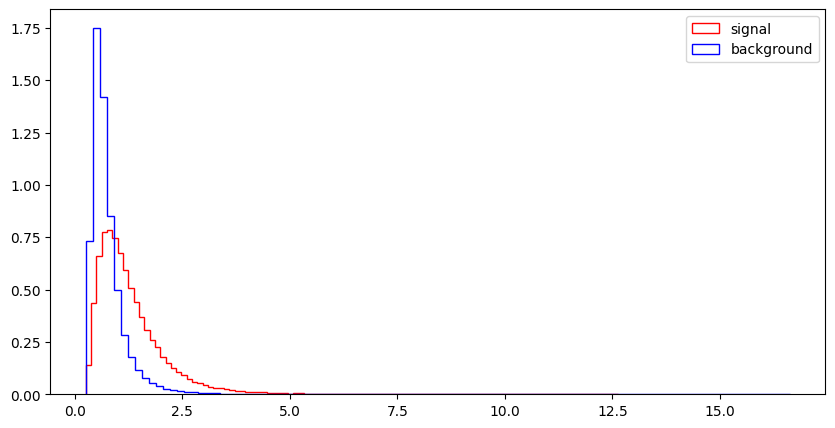

l_1_eta


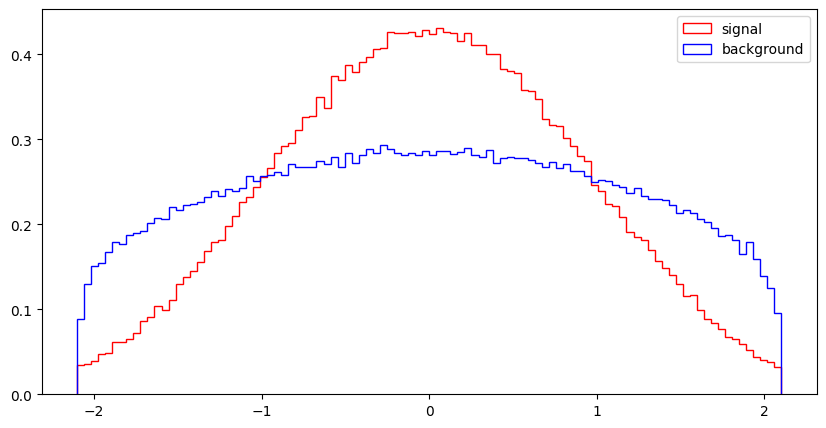

l_1_phi


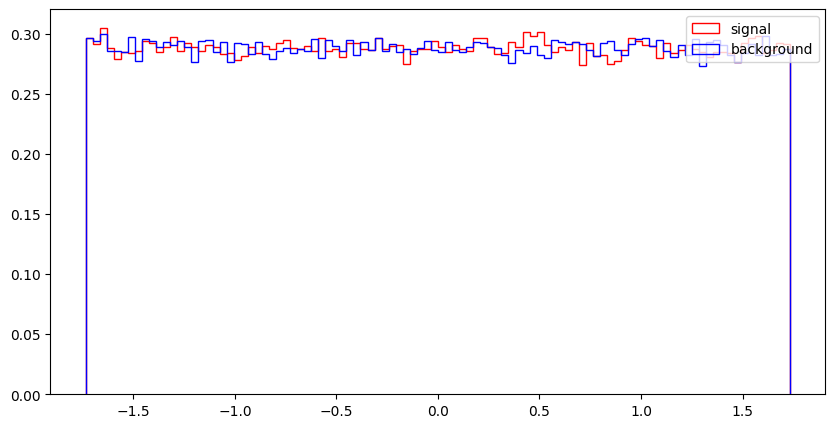

l_2_pT


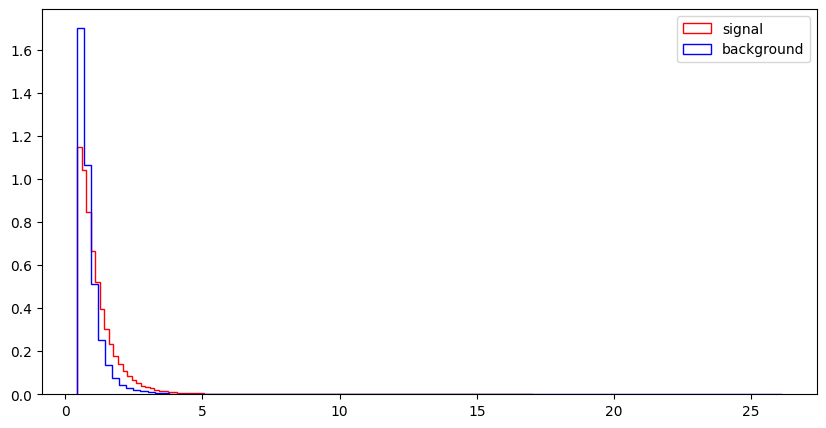

l_2_eta


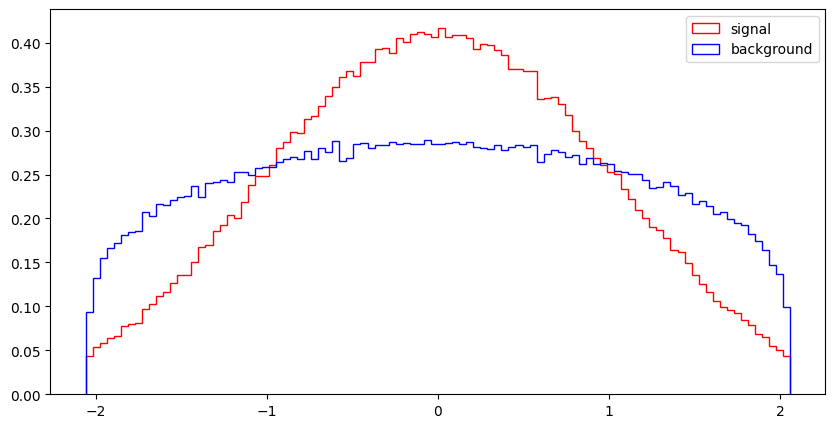

l_2_phi


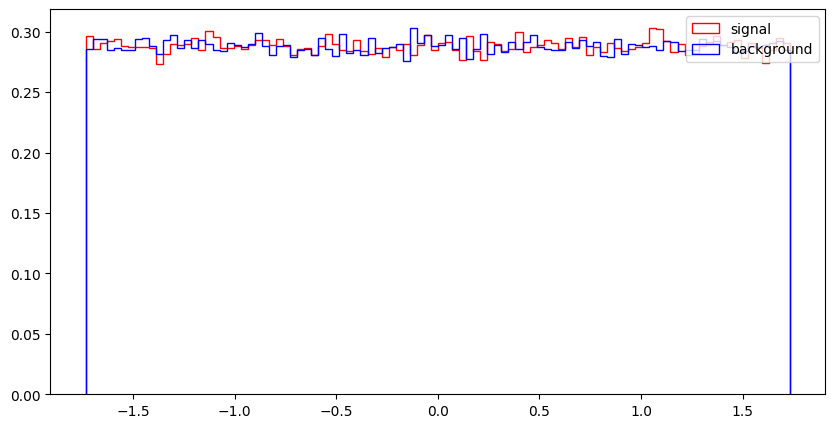

MET


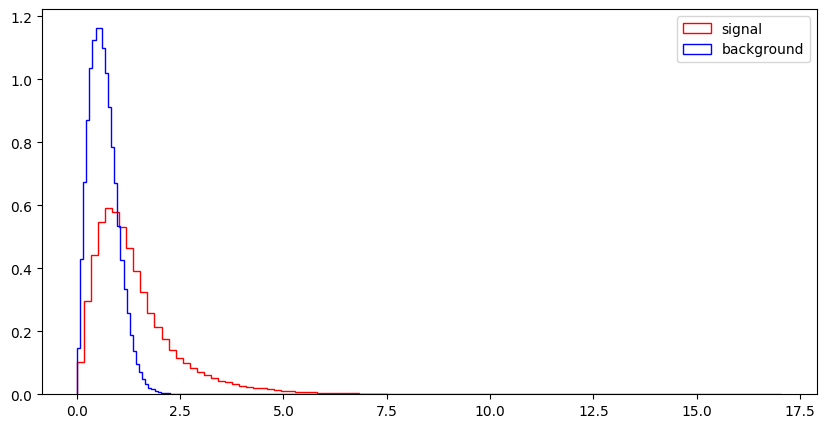

MET_phi


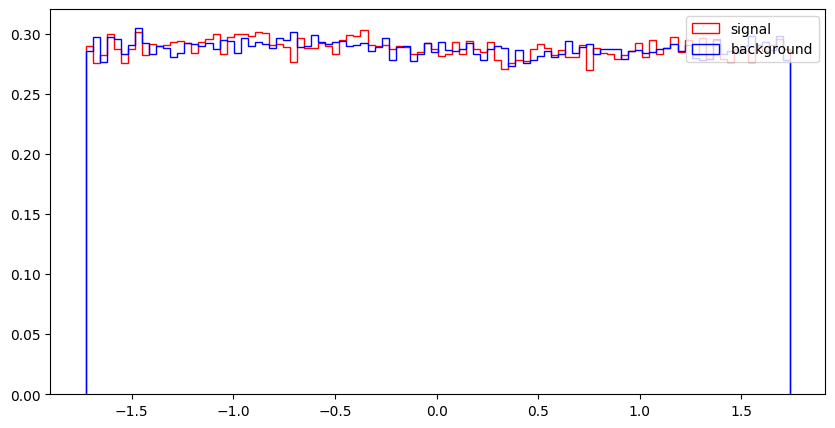

MET_rel


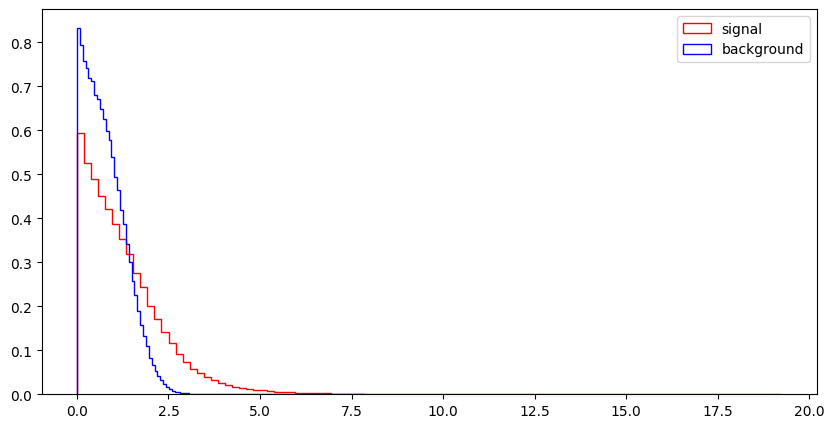

axial_MET


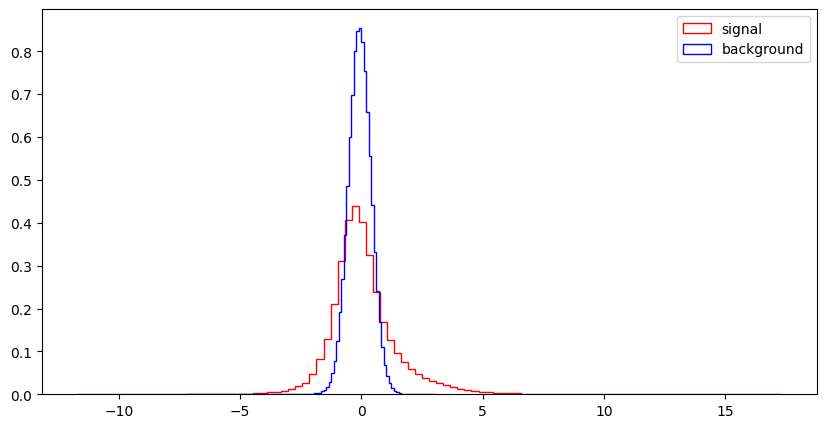

M_R


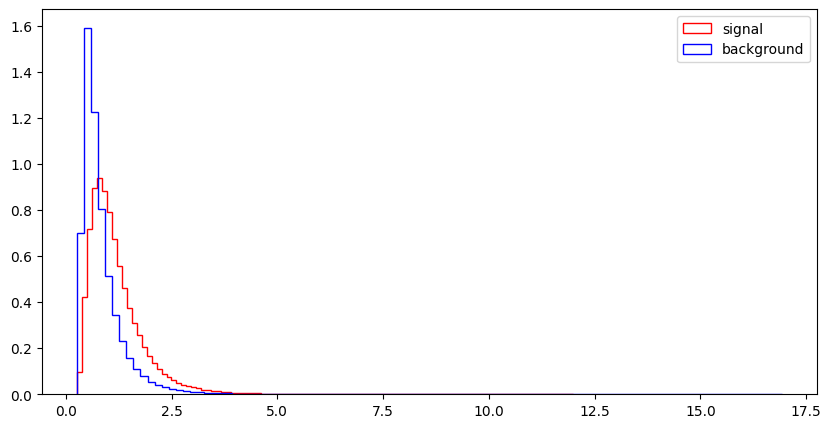

M_TR_2


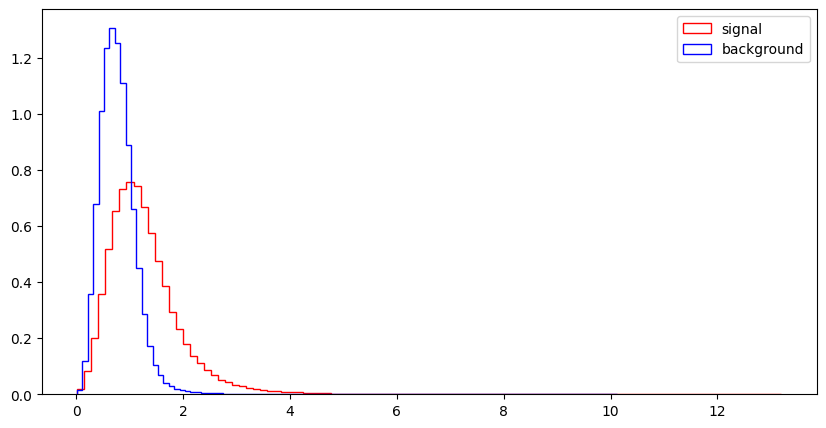

R


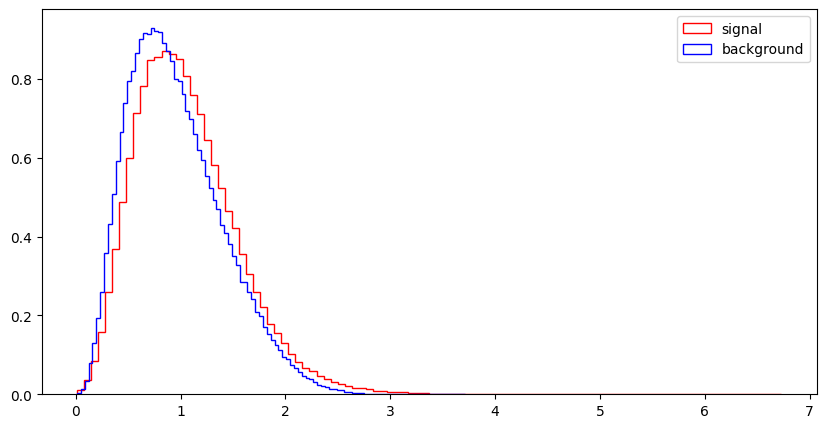

MT2


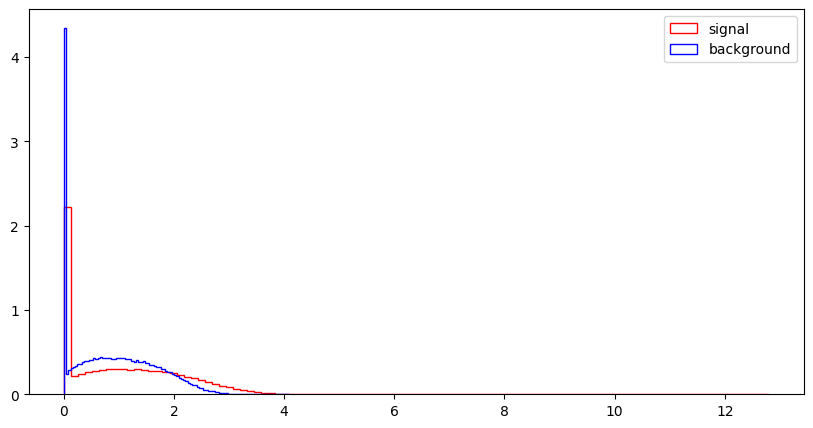

S_R


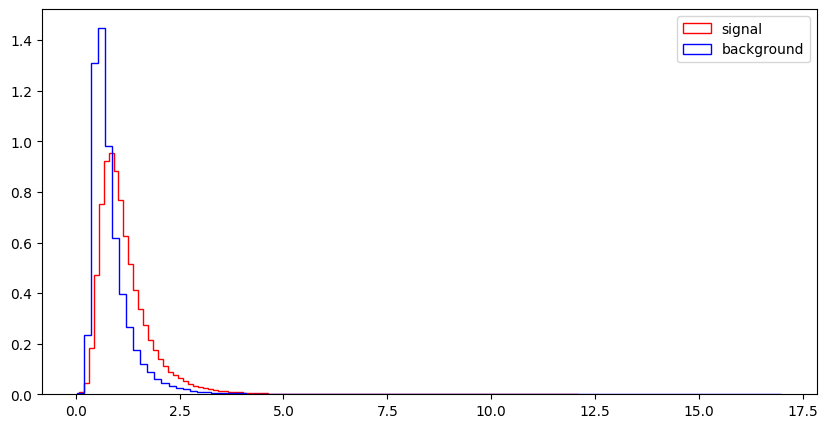

M_Delta_R


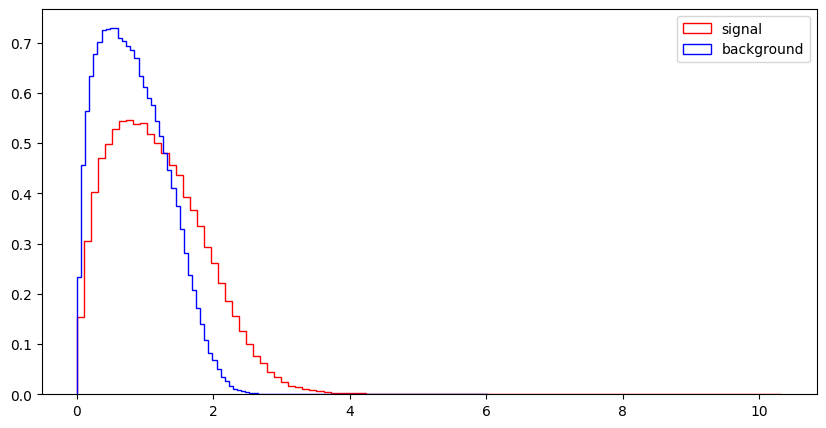

dPhi_r_b


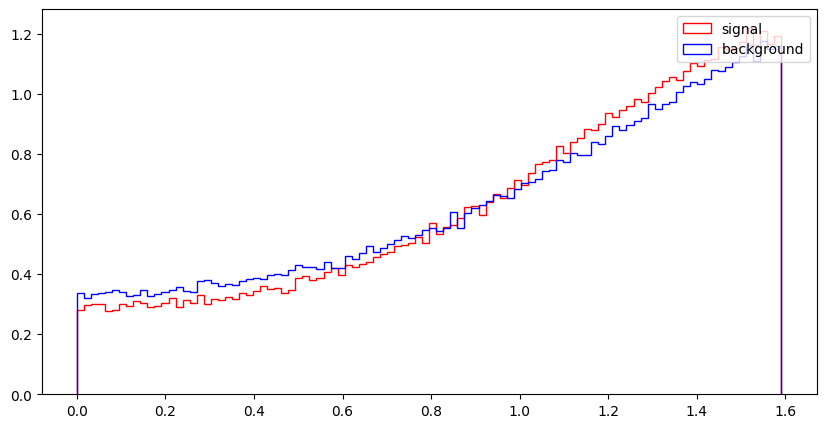

cos_theta_r1


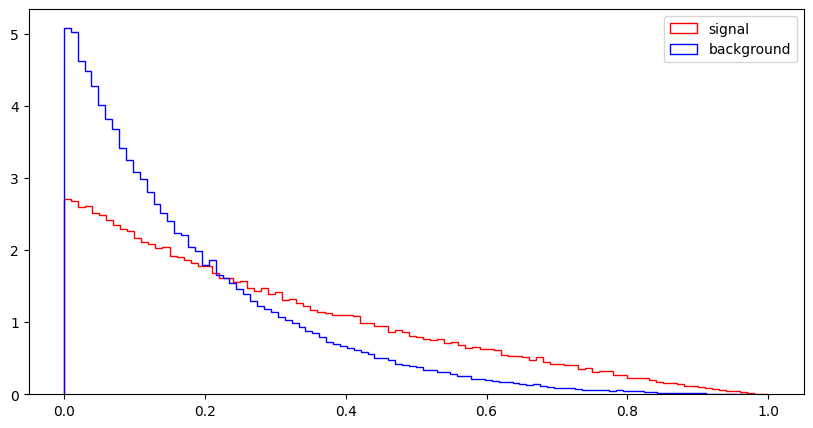

In [88]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

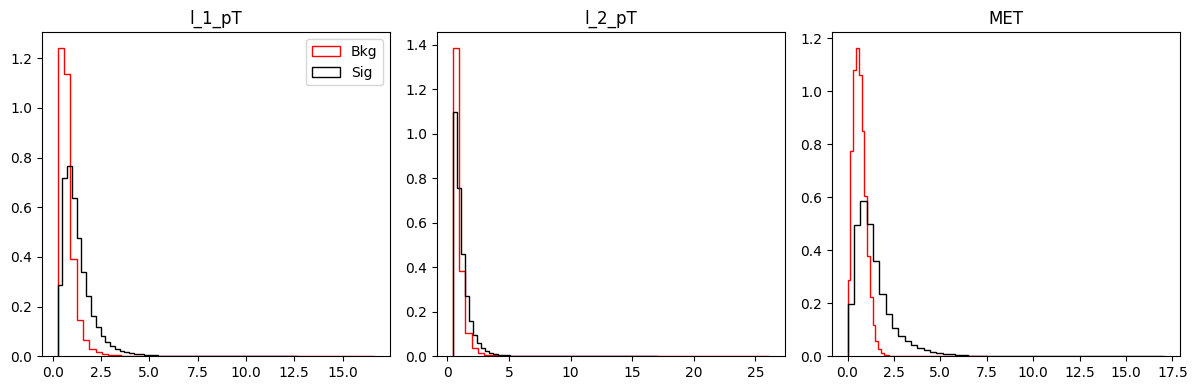

In [89]:
low_level = ["l_1_pT", "l_2_pT", "MET"]

plt.figure(figsize=(12, 4))
for i, var in enumerate(low_level):
    plt.subplot(1, 3, i+1)
    plt.hist(df_bkg[var], bins=50, density=True, histtype='step', label='Bkg', color='red')
    plt.hist(df_sig[var], bins=50, density=True, histtype='step', label='Sig', color='black')
    plt.title(var)
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()

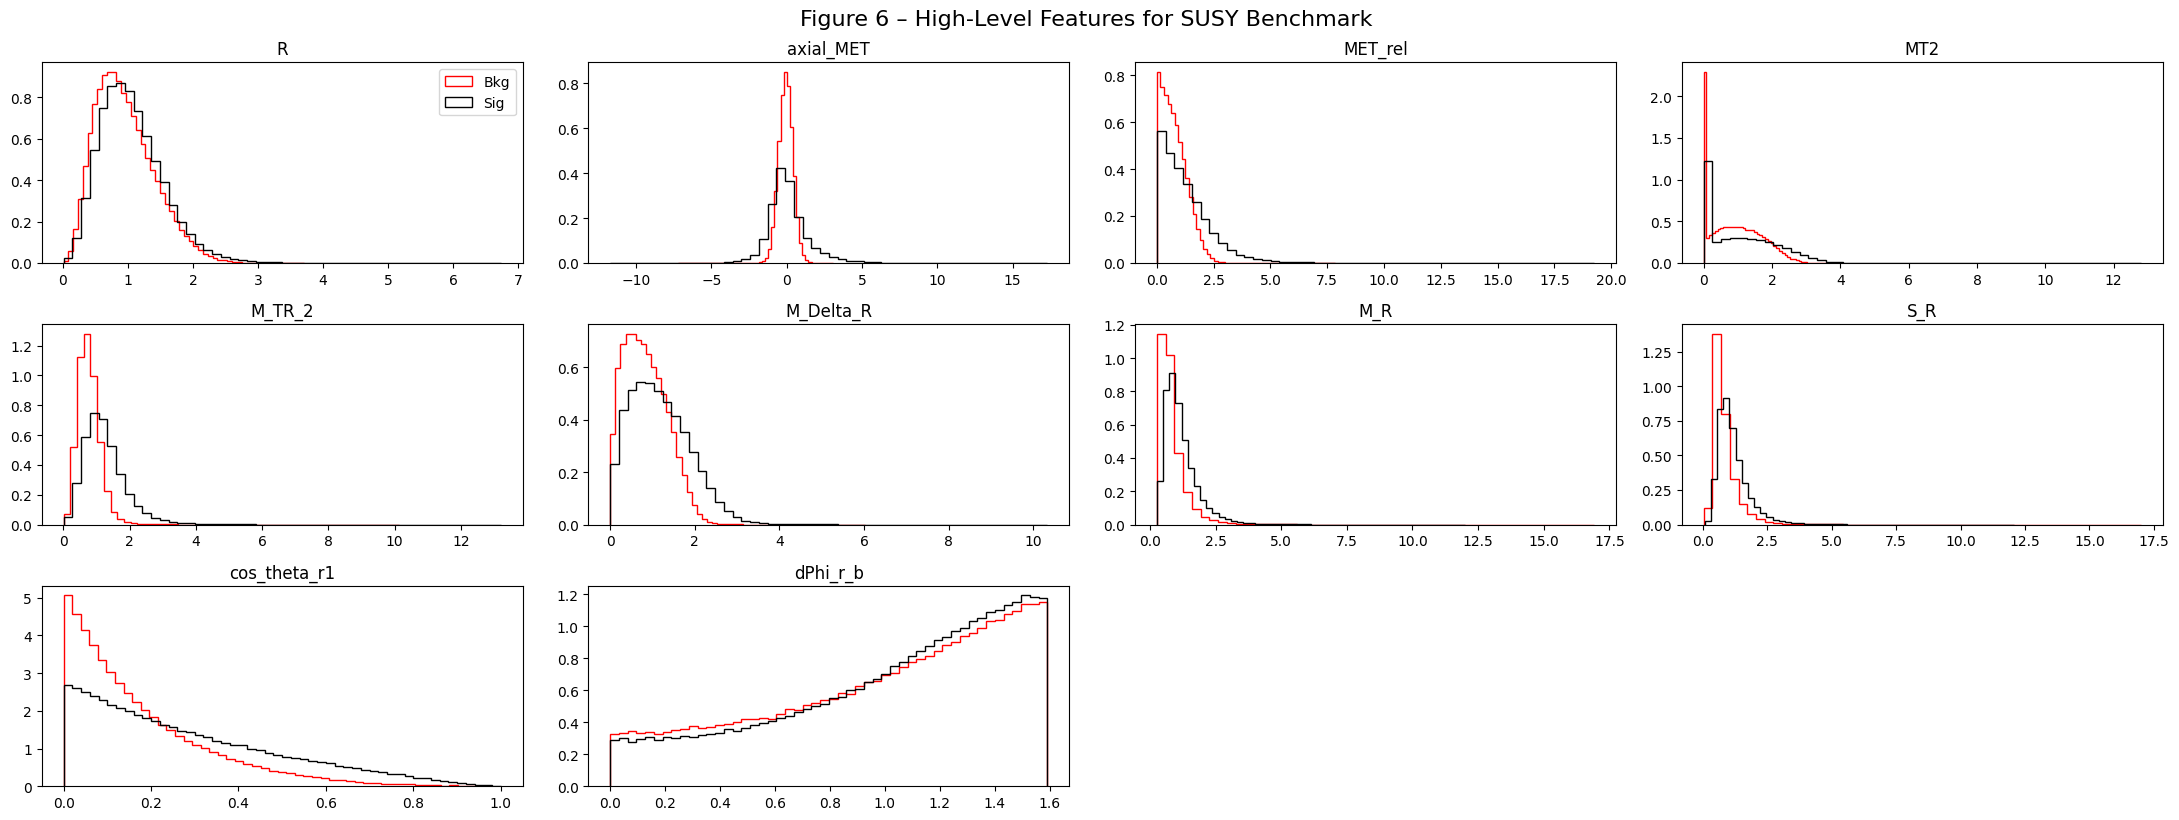

In [90]:
high_level = ["R", "axial_MET", "MET_rel", "MT2", "M_TR_2","M_Delta_R", "M_R", "S_R", "cos_theta_r1", "dPhi_r_b"]

plt.figure(figsize=(22, 8))
for i, var in enumerate(high_level):
    plt.subplot(3, 4, i+1)
    plt.hist(df_bkg[var], bins=50, density=True, histtype='step', label='Bkg', color='red')
    plt.hist(df_sig[var], bins=50, density=True, histtype='step', label='Sig', color='black')
    plt.title(var)
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.suptitle("Figure 6 – High-Level Features for SUSY Benchmark", fontsize=16, y=1.02)
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [91]:
### part a
def pairplot(df_sig, df_bkg, features, sample_size=5000):
    sig = df_sig[features].sample(n=sample_size, random_state=1)
    bkg = df_bkg[features].sample(n=sample_size, random_state=1)
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            x = features[i]
            y = features[j]
            plt.figure(figsize=(5, 5))
            plt.scatter(bkg[x], bkg[y], s=1, color='red', alpha=0.5, label='Background')
            plt.scatter(sig[x], sig[y], s=1, color='black', alpha=0.5, label='Signal')
            plt.xlabel(x)
            plt.ylabel(y)
            plt.title(f"{y} vs {x}")
            plt.legend()
            plt.tight_layout()
            plt.show()

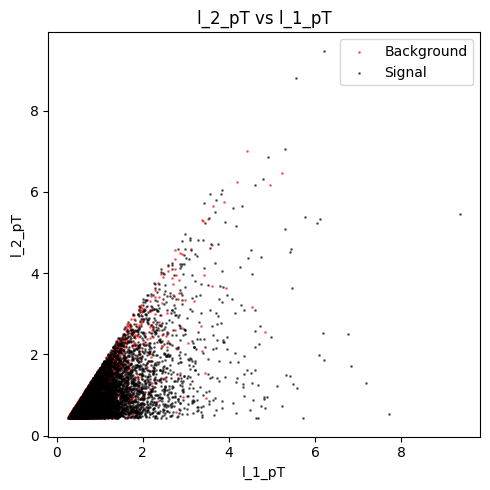

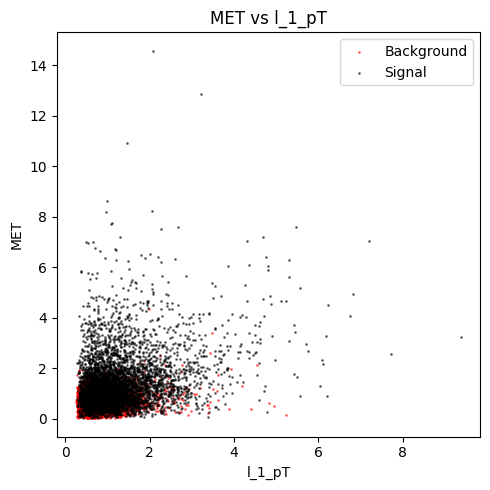

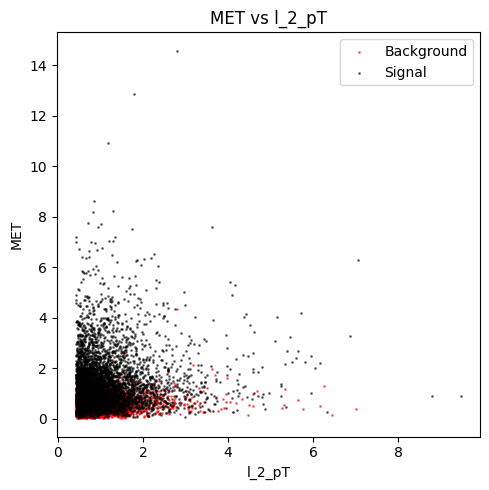

In [92]:
pairplot(df_sig,df_bkg,low_level)

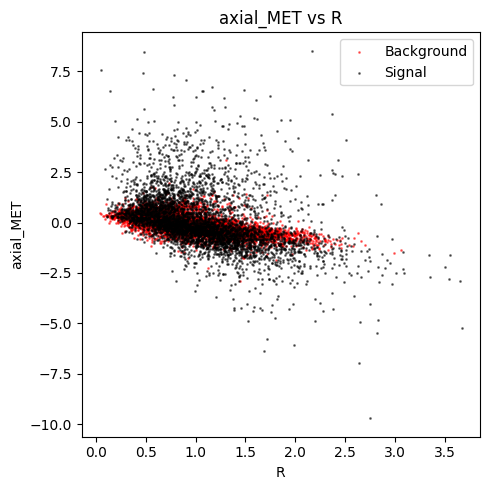

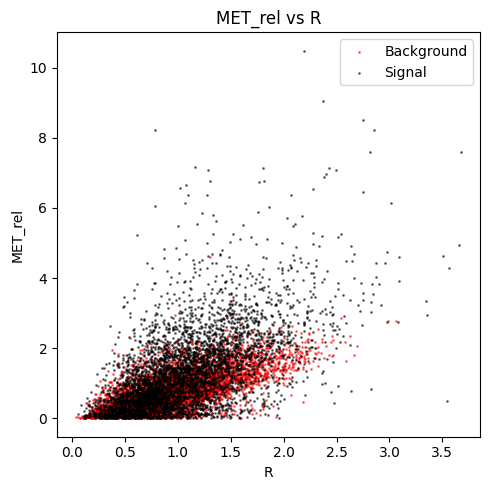

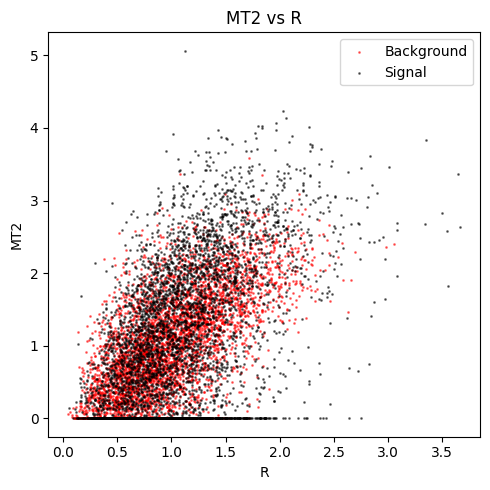

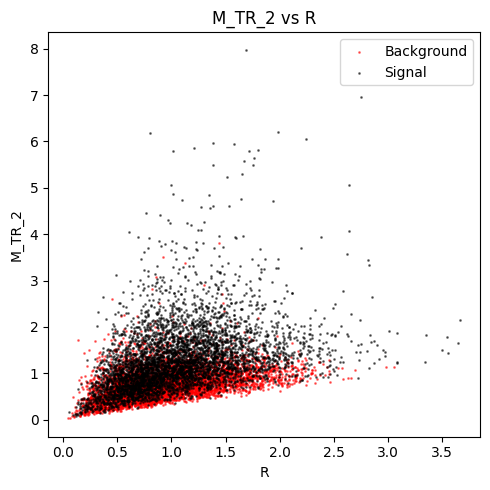

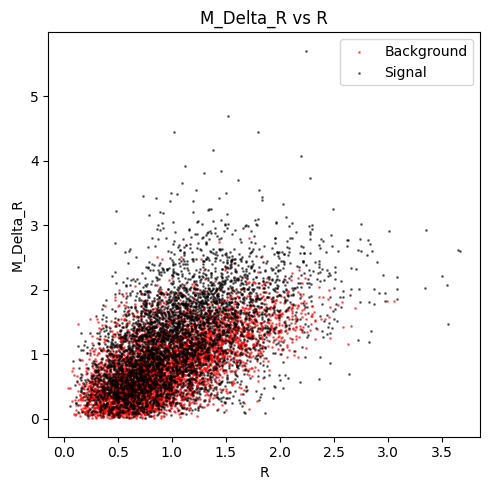

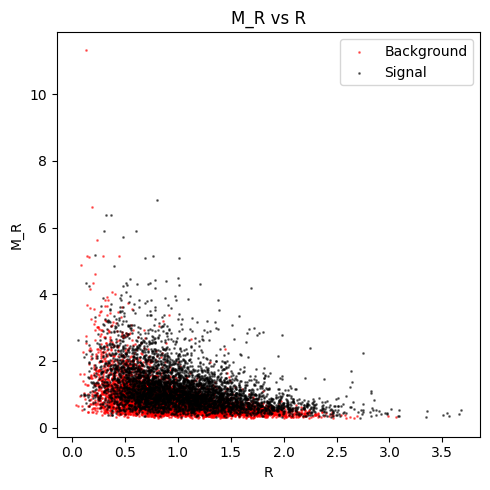

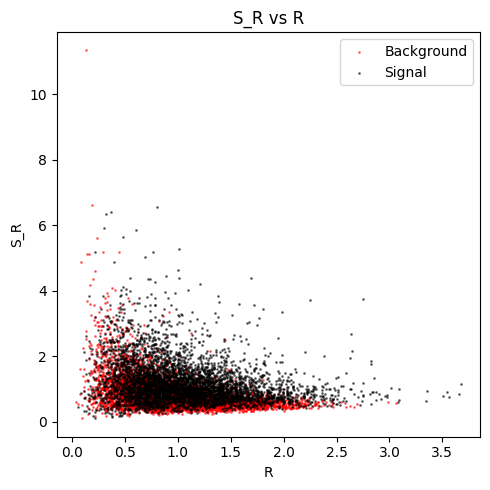

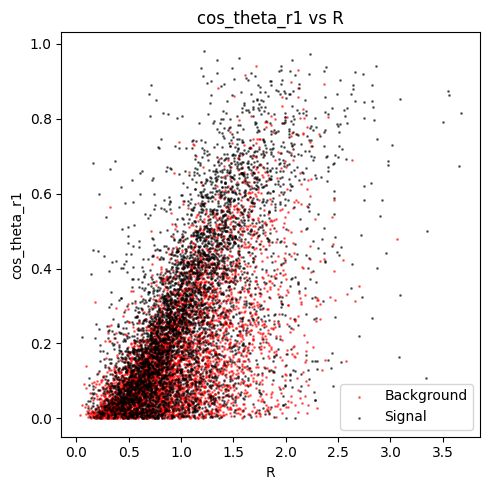

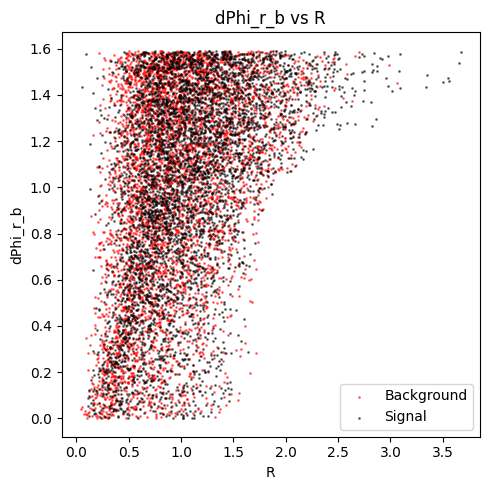

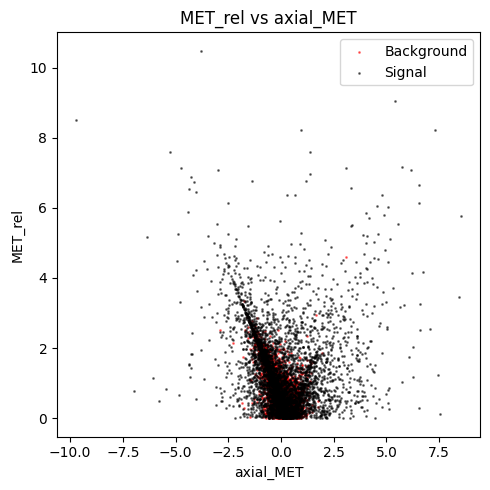

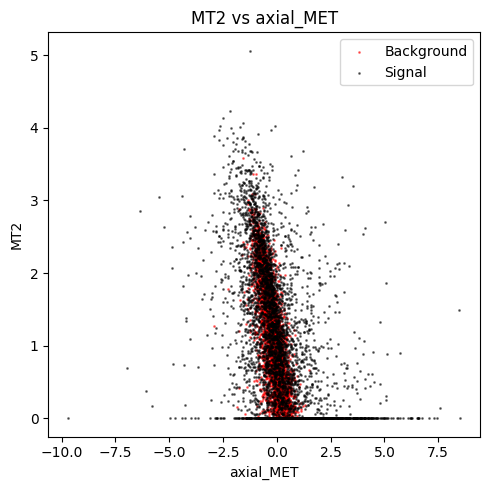

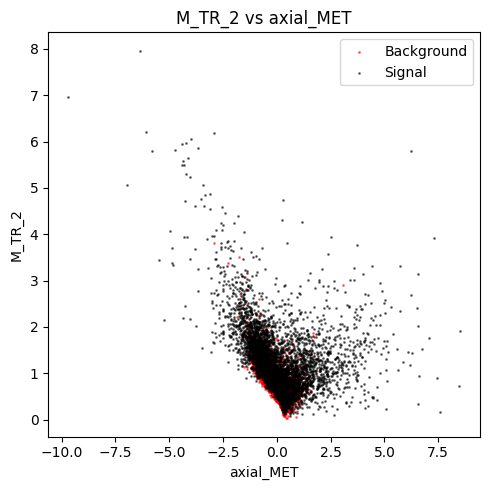

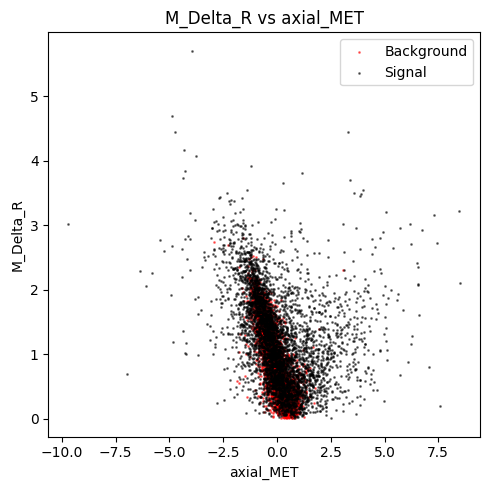

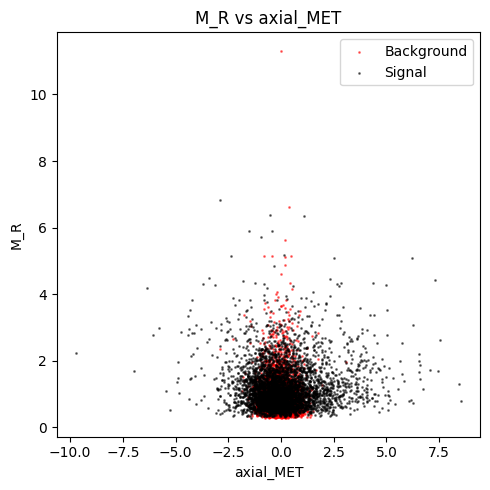

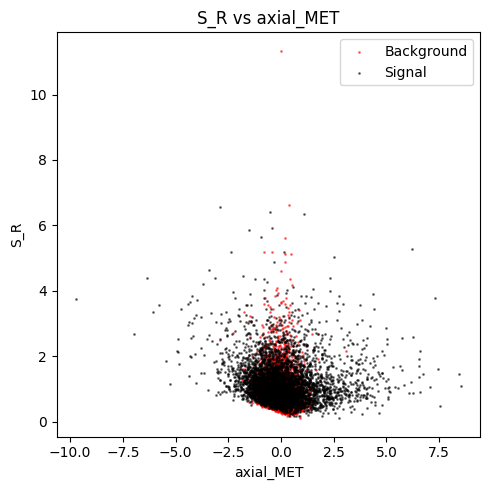

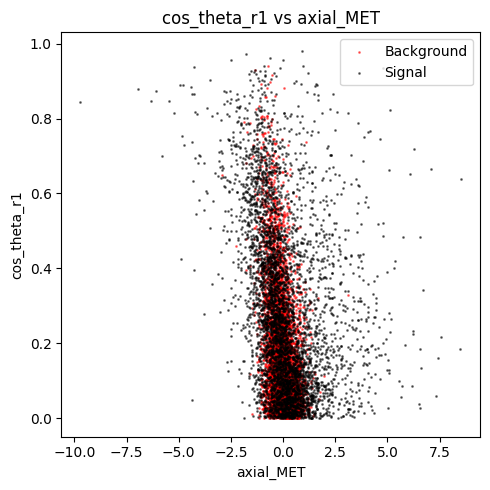

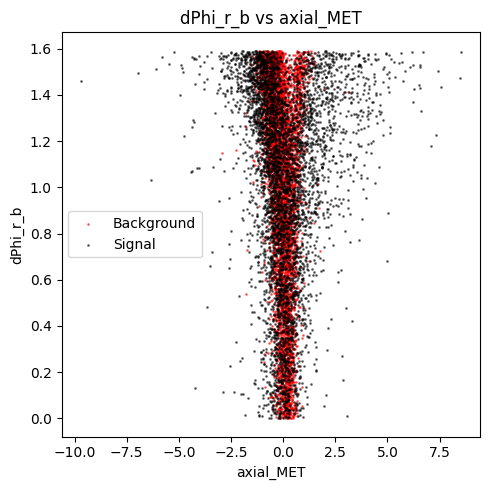

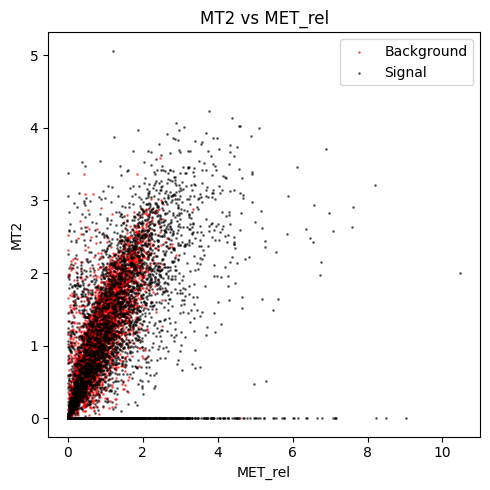

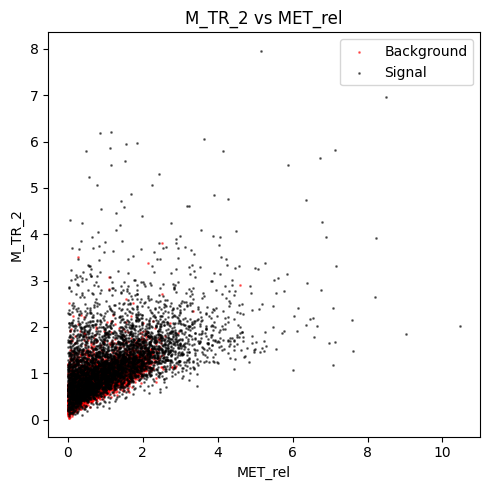

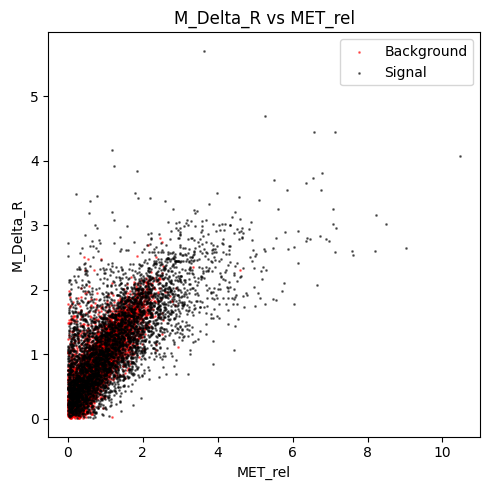

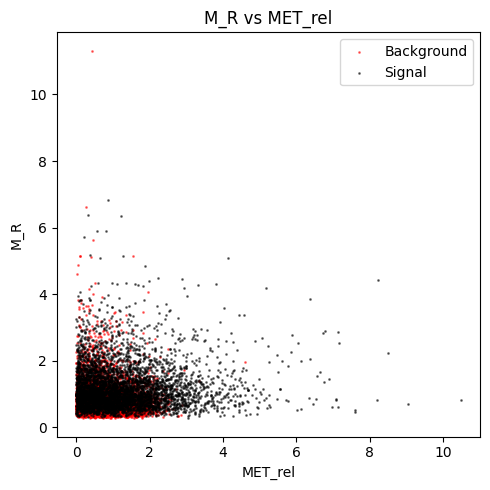

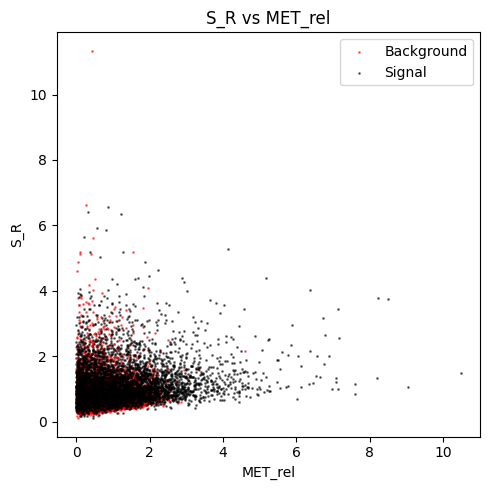

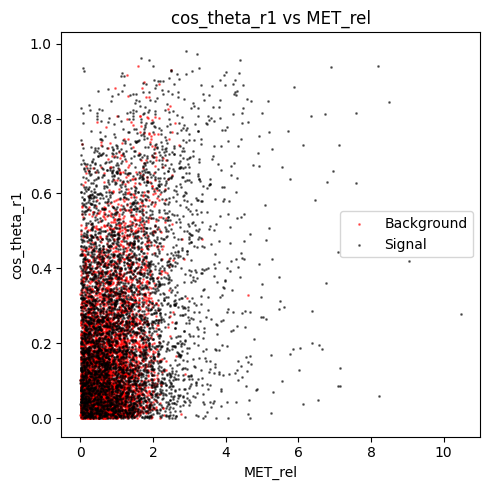

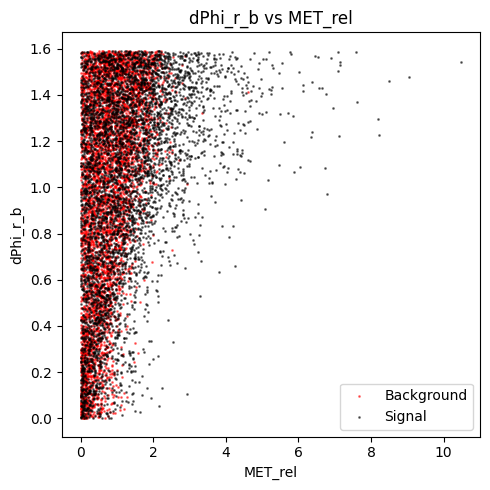

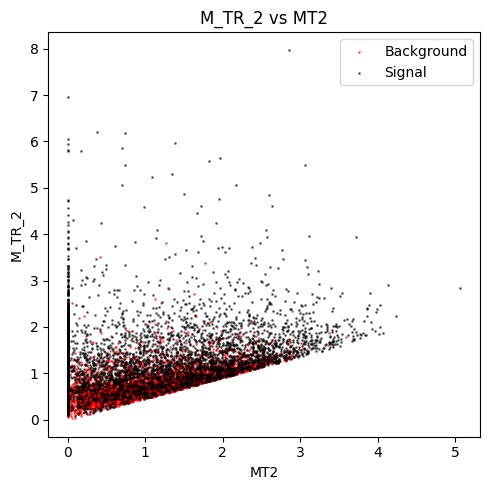

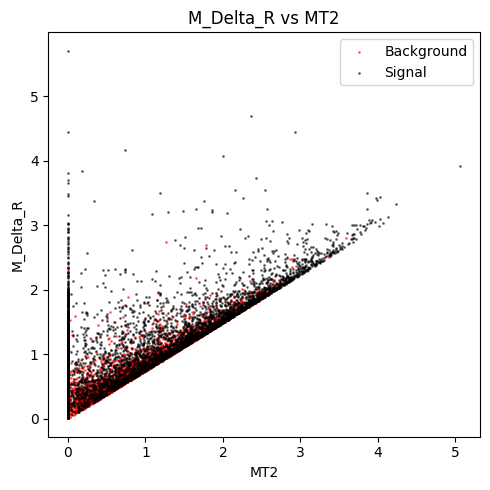

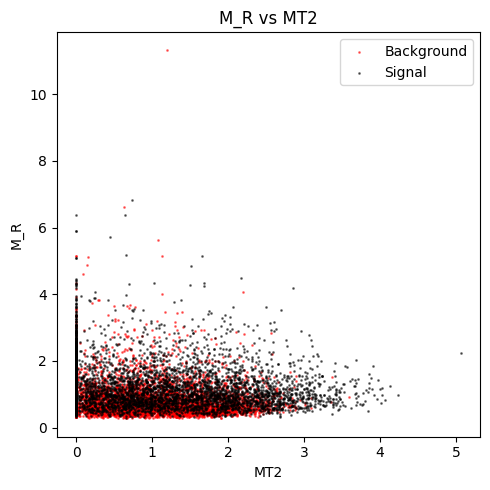

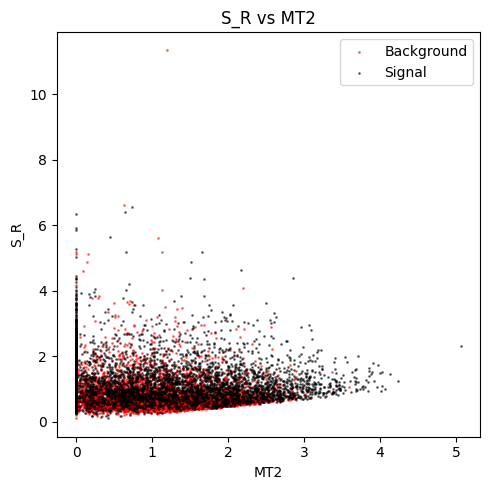

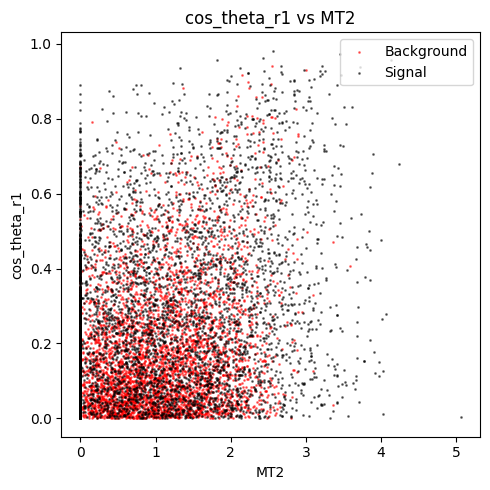

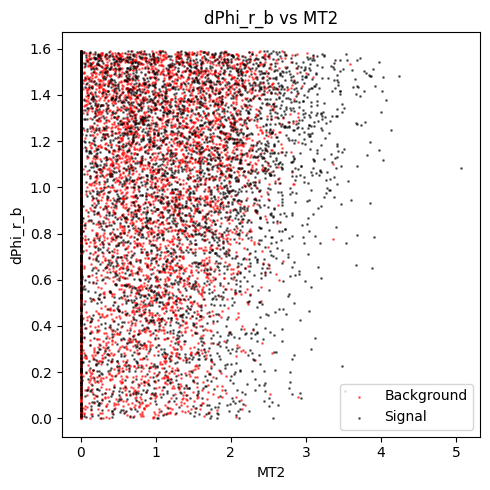

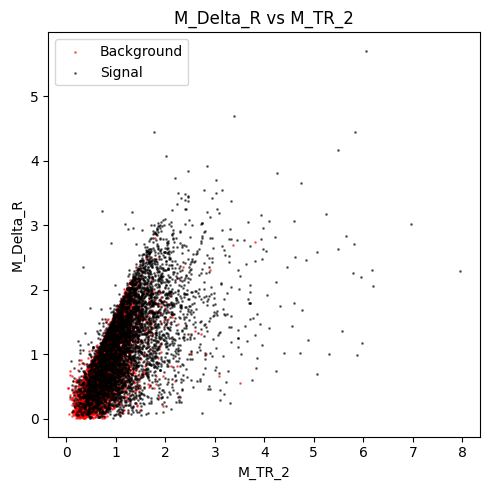

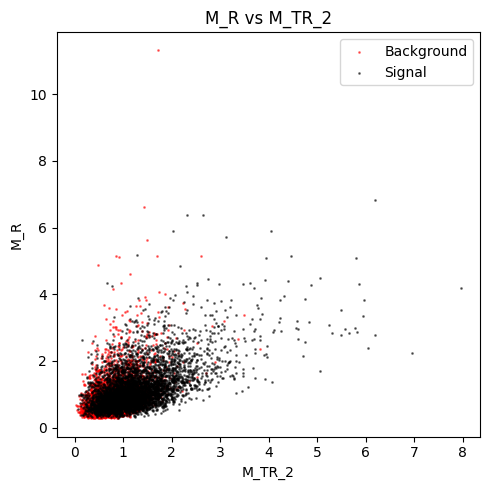

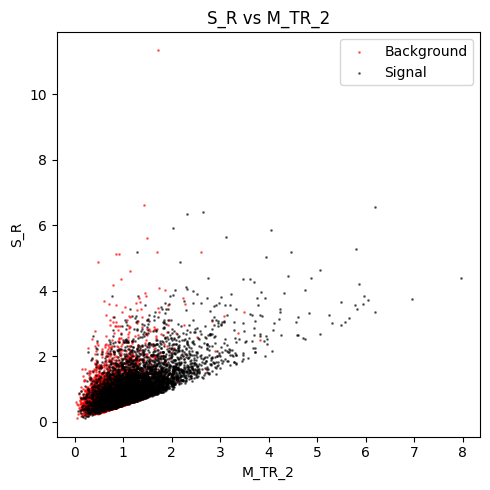

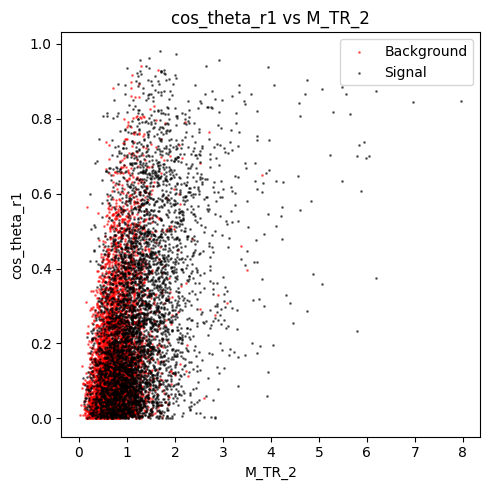

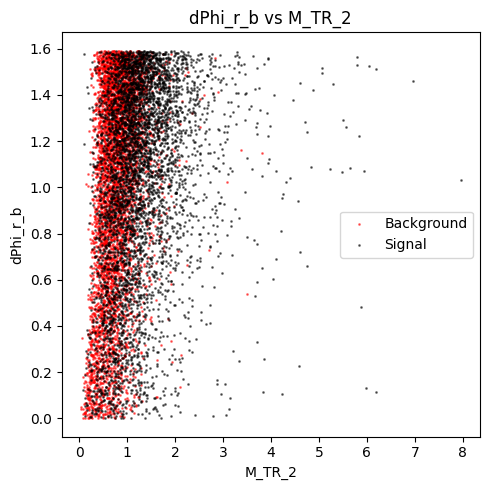

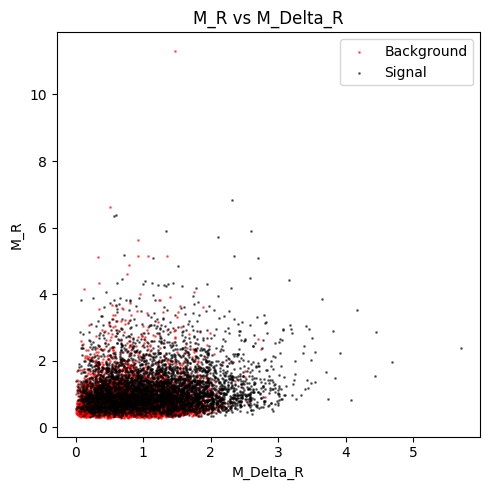

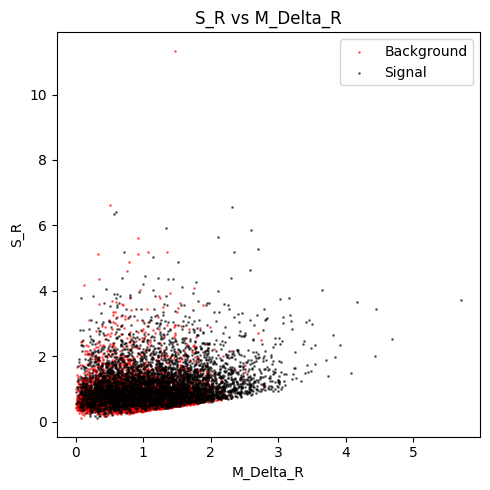

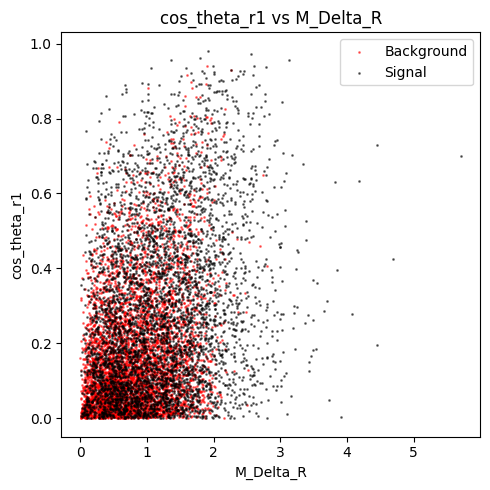

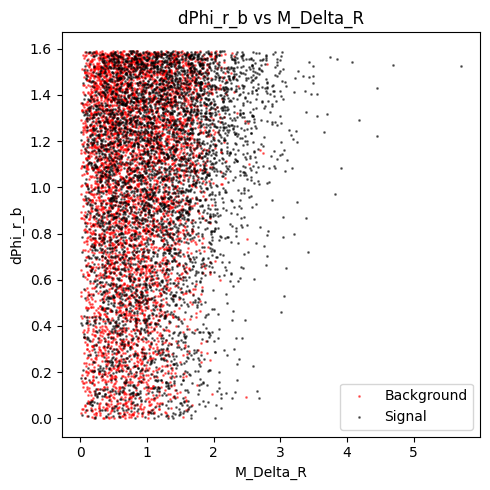

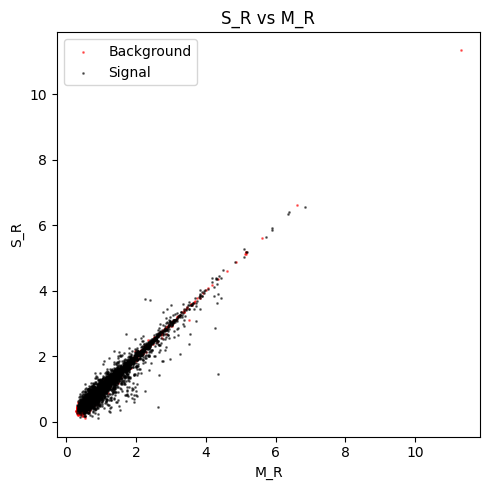

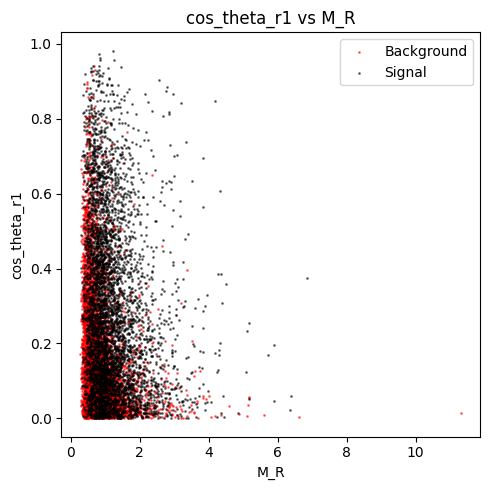

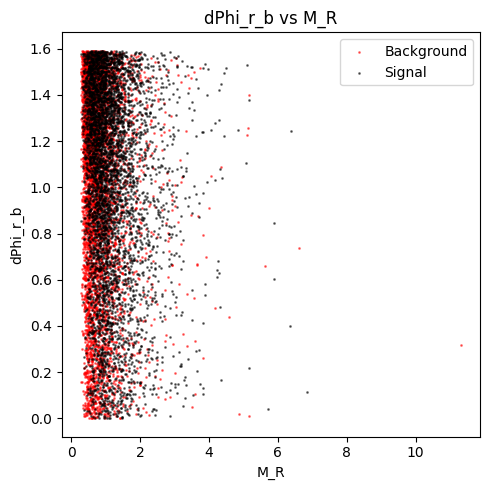

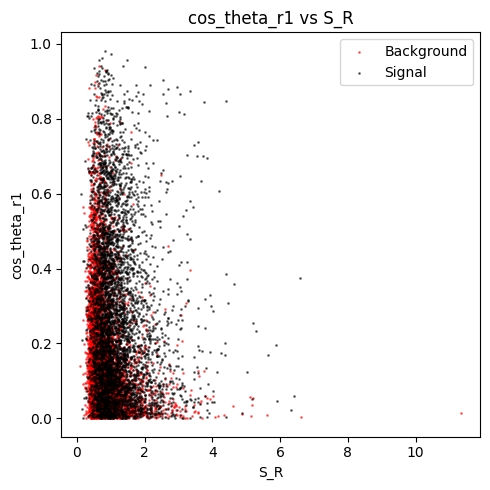

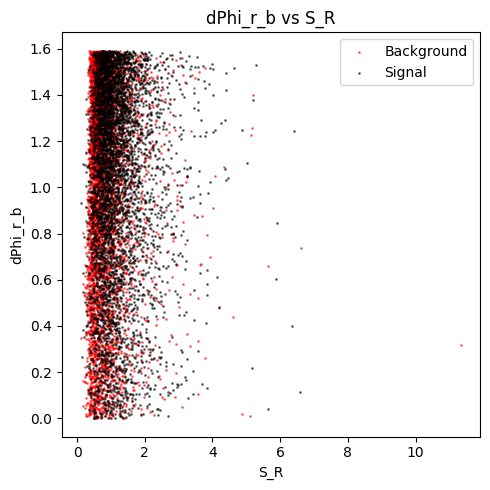

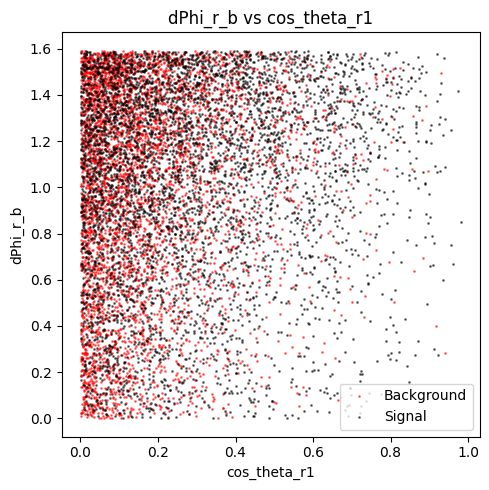

In [93]:
pairplot(df_sig,df_bkg,high_level)

In [94]:
### part b - using 2d histograms as a faster method of pairplotting
def hist_pair(df_sig, df_bkg, features, sample_size=10000, bins=50):
    sig = df_sig[features].sample(n=sample_size, random_state=1)
    bkg = df_bkg[features].sample(n=sample_size, random_state=1)
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            x = features[i]
            y = features[j]
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].hist2d(bkg[x], bkg[y], bins=bins, cmap="Reds")
            axes[0].set_title(f"Background: {y} vs {x}")
            axes[0].set_xlabel(x)
            axes[0].set_ylabel(y)
            axes[1].hist2d(sig[x], sig[y], bins=bins, cmap="Greys")
            axes[1].set_title(f"Signal: {y} vs {x}")
            axes[1].set_xlabel(x)
            axes[1].set_ylabel(y)
            plt.tight_layout()
            plt.show()

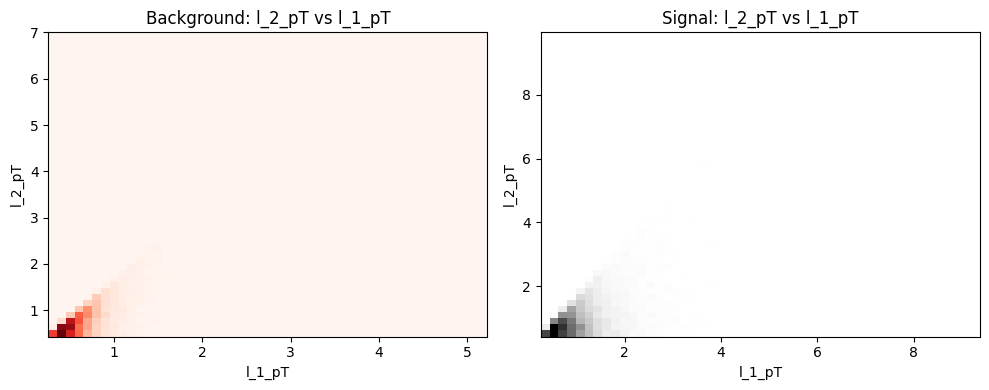

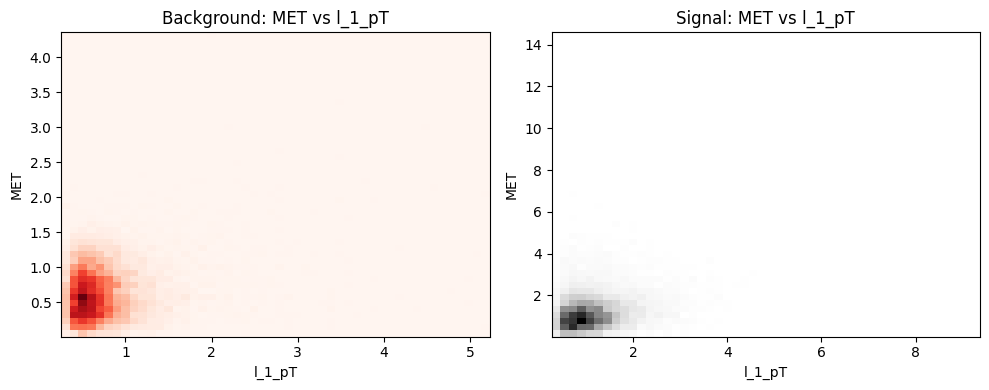

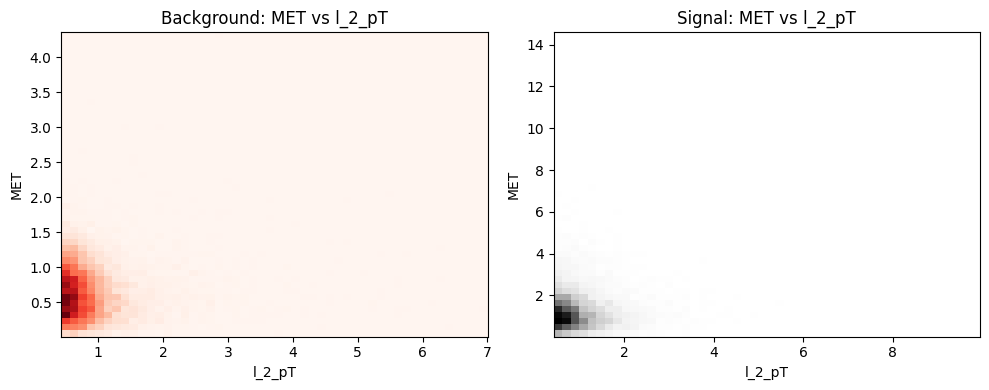

In [95]:
hist_pair(df_sig,df_bkg,low_level)

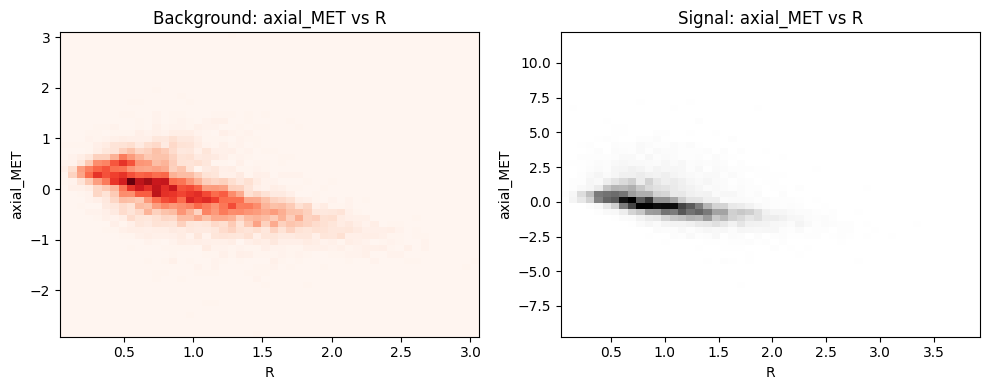

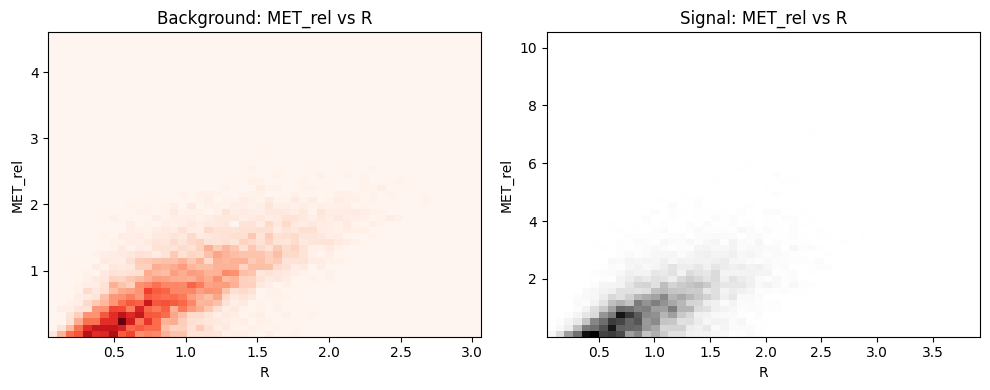

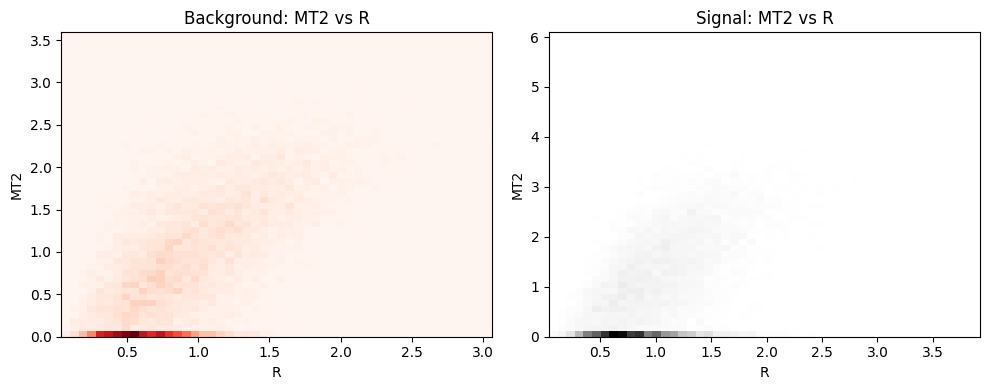

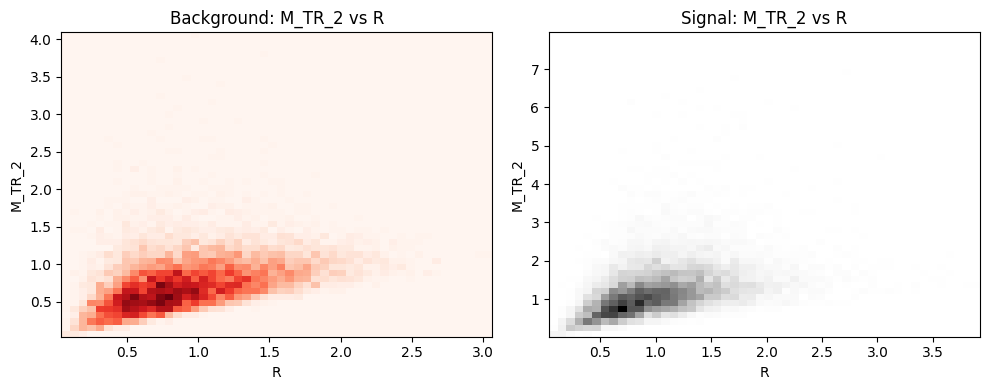

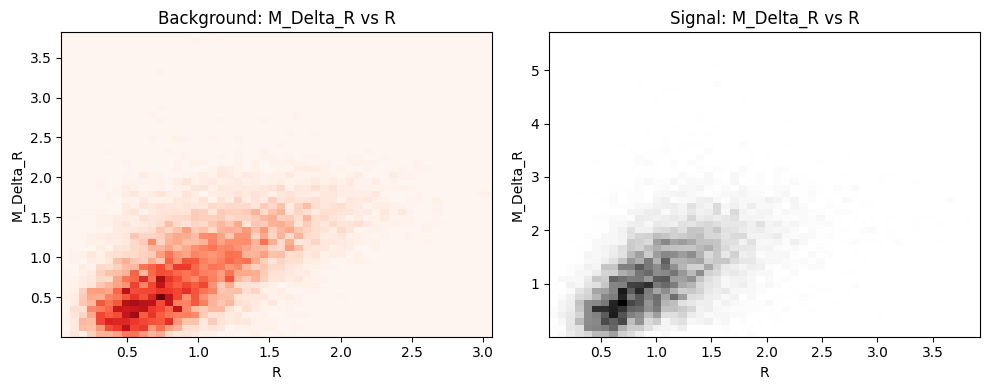

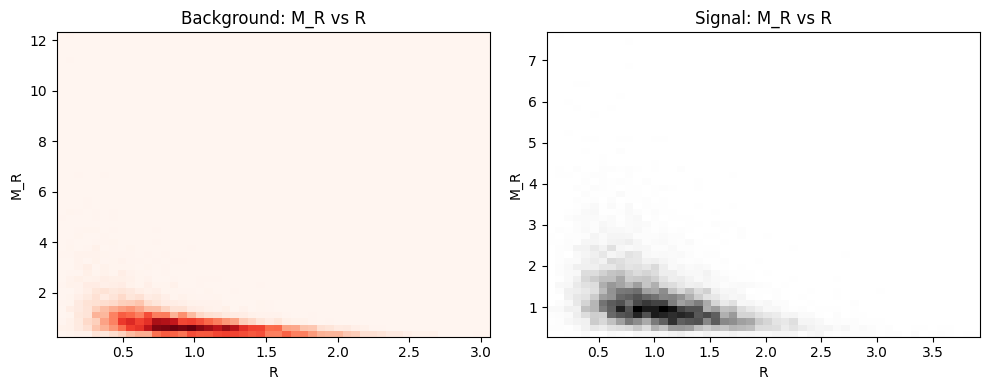

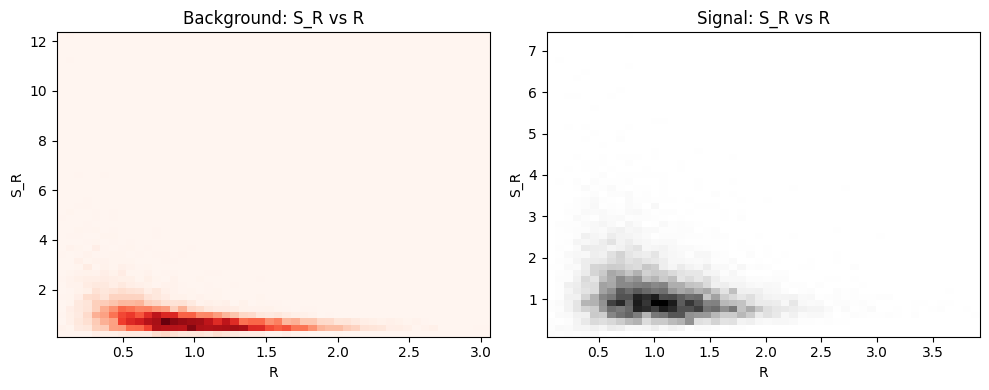

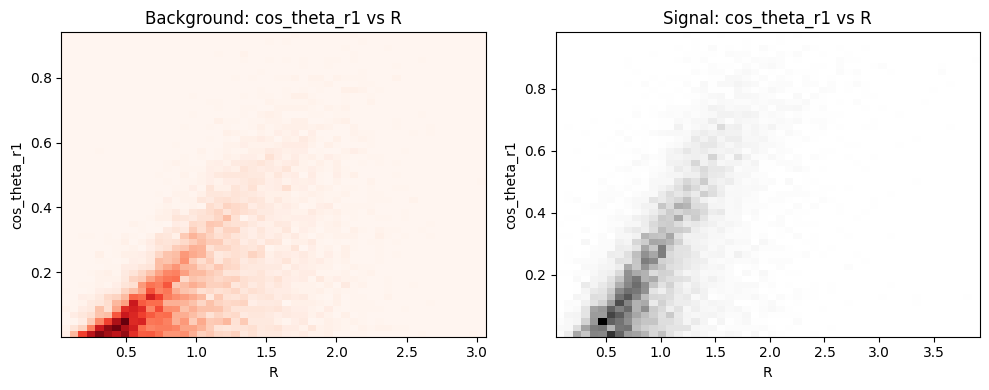

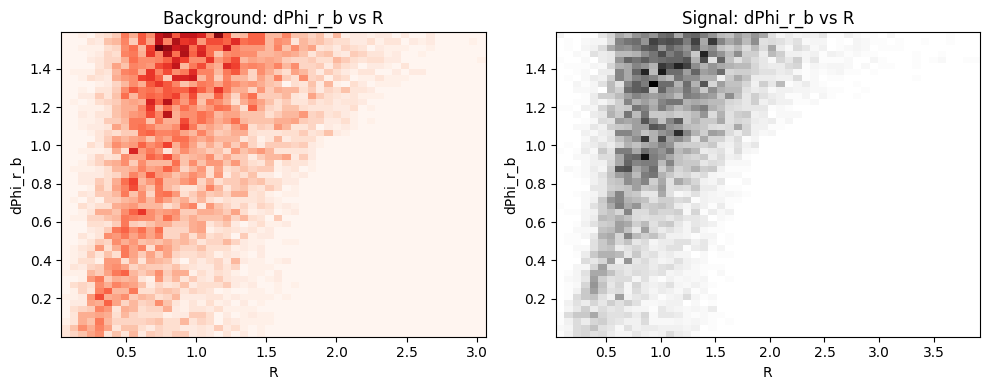

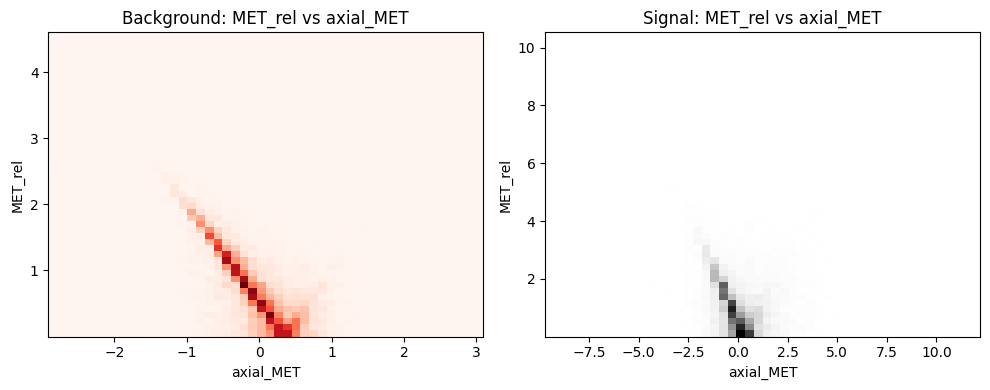

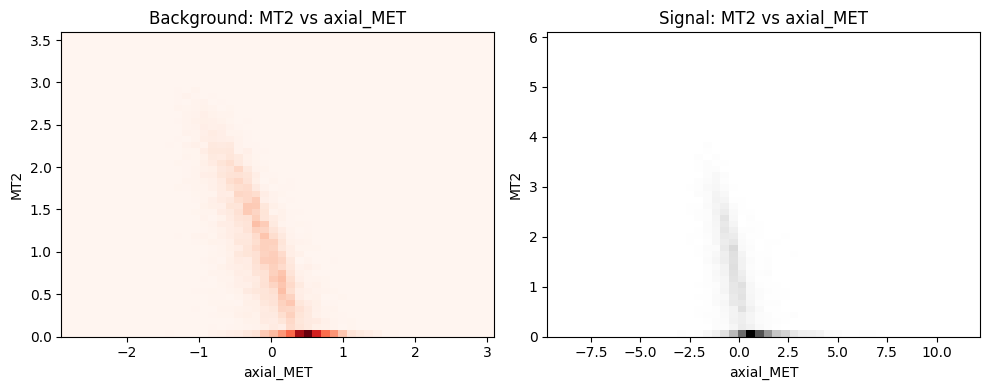

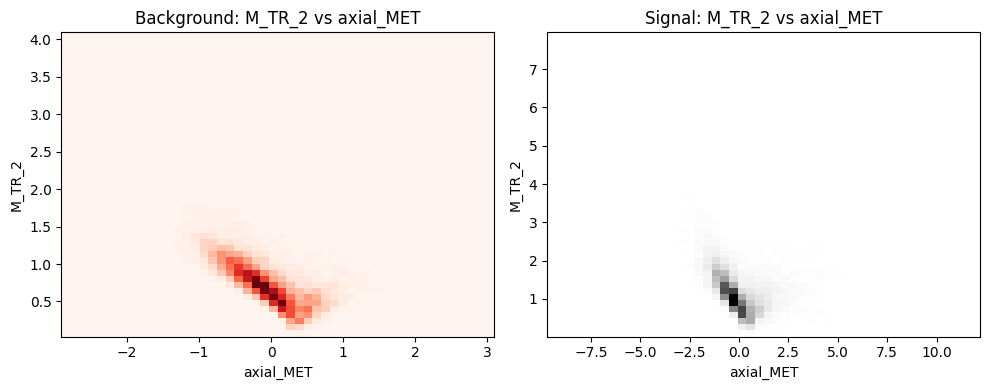

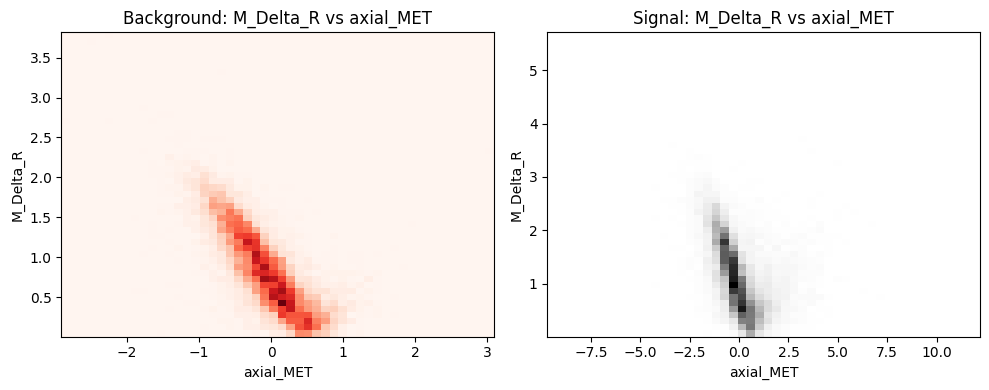

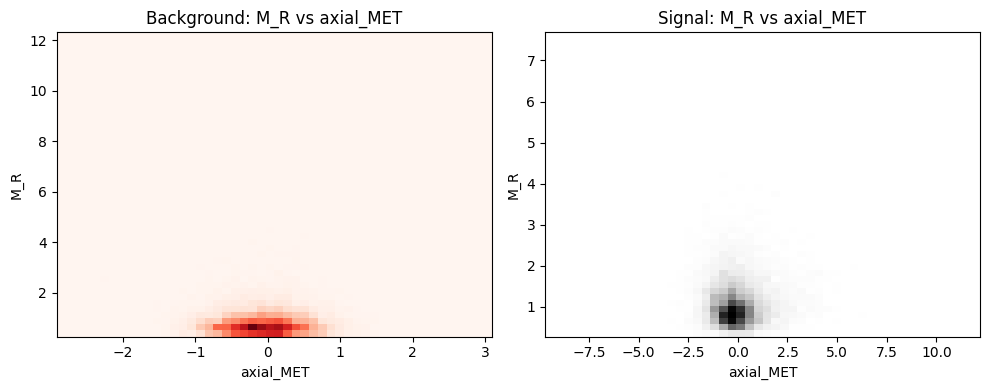

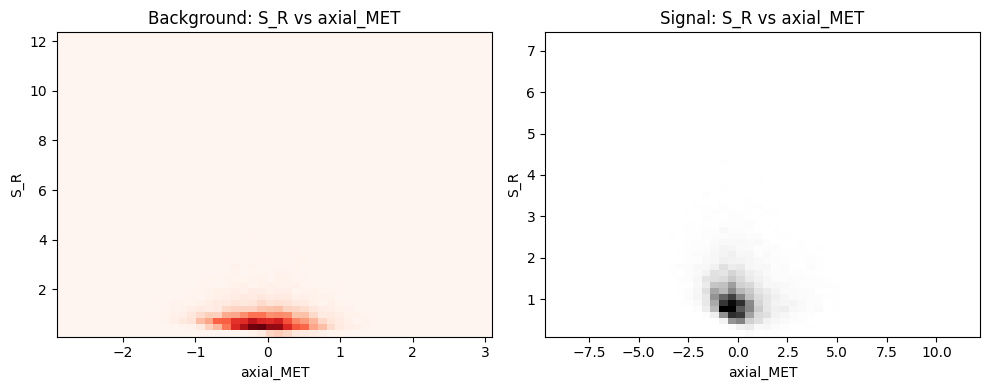

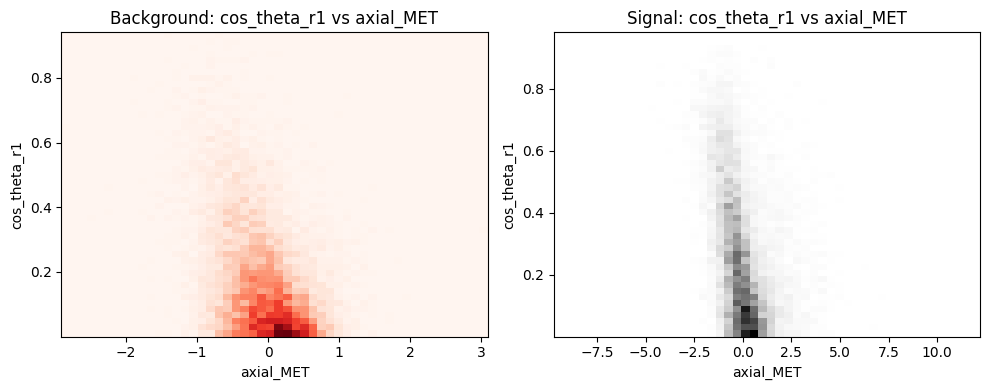

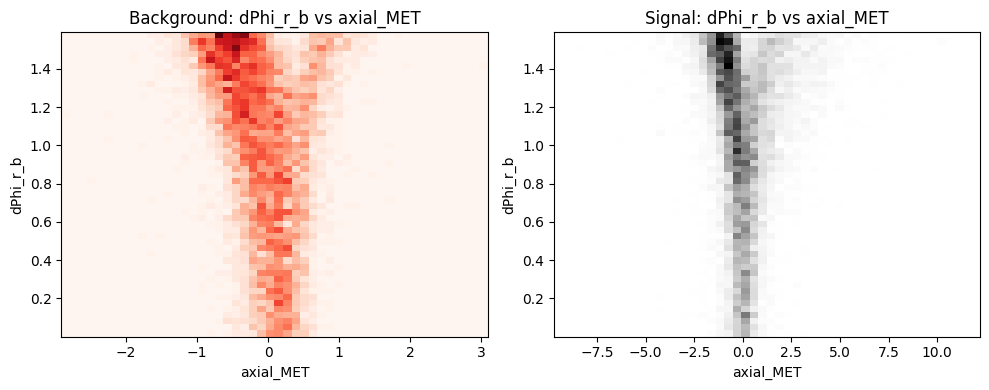

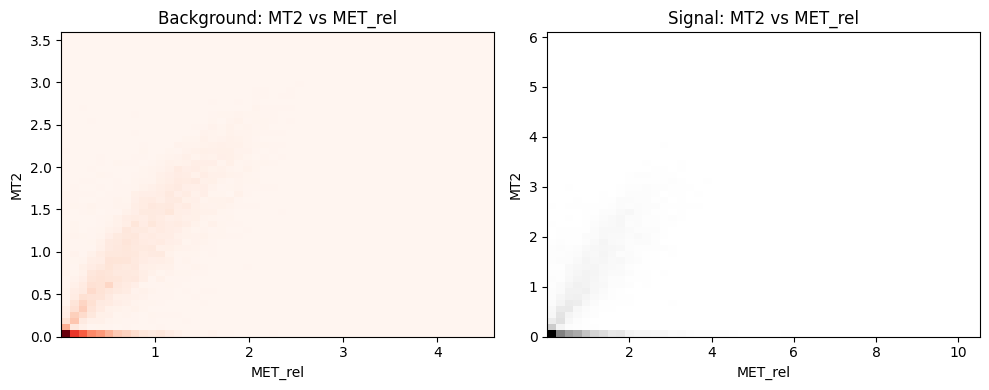

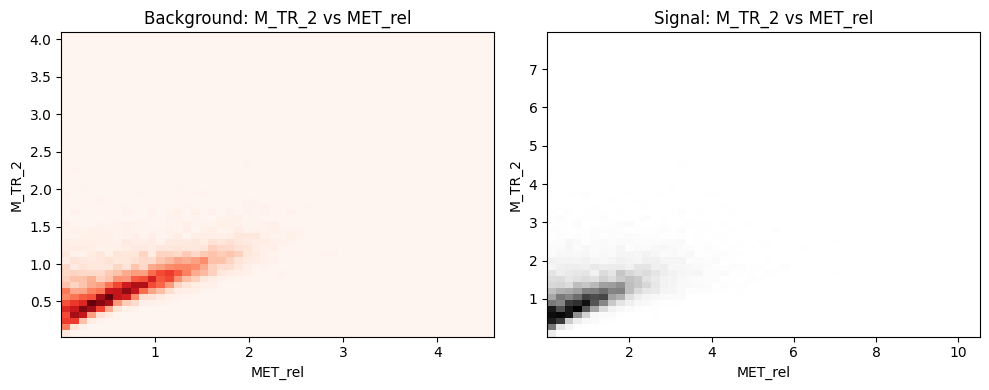

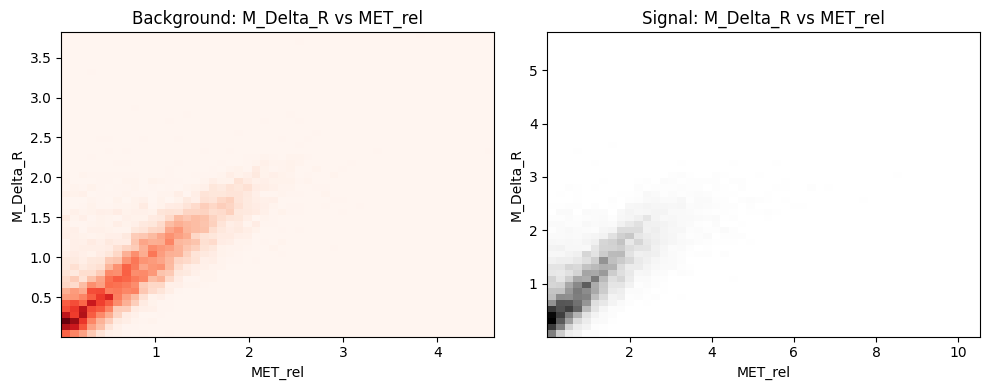

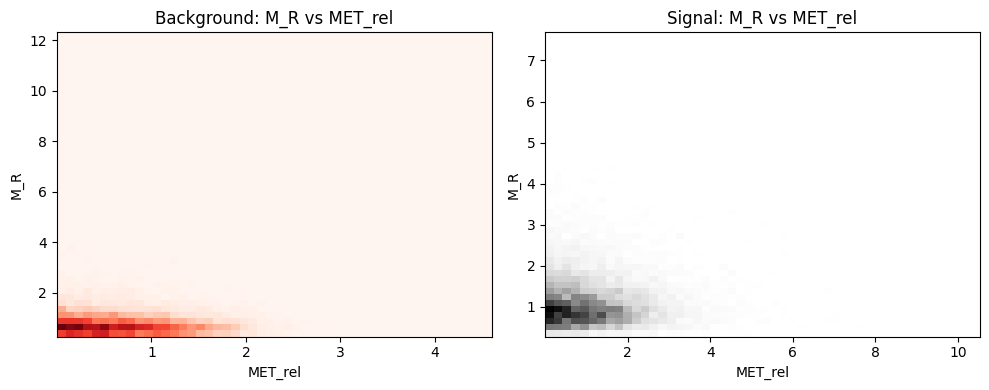

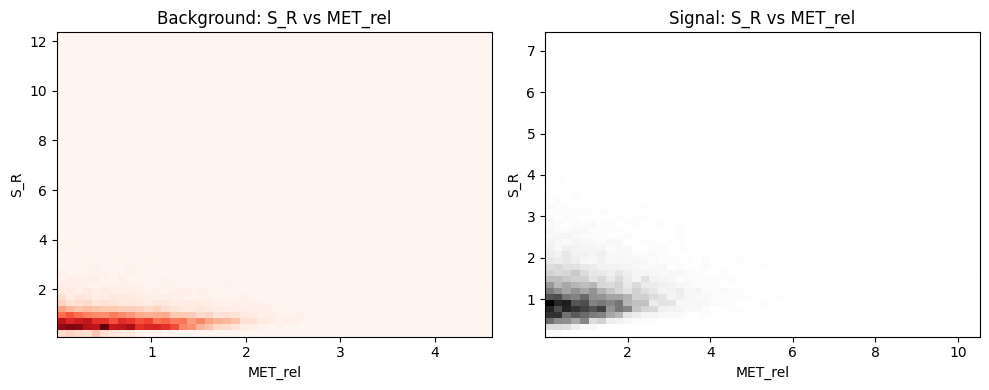

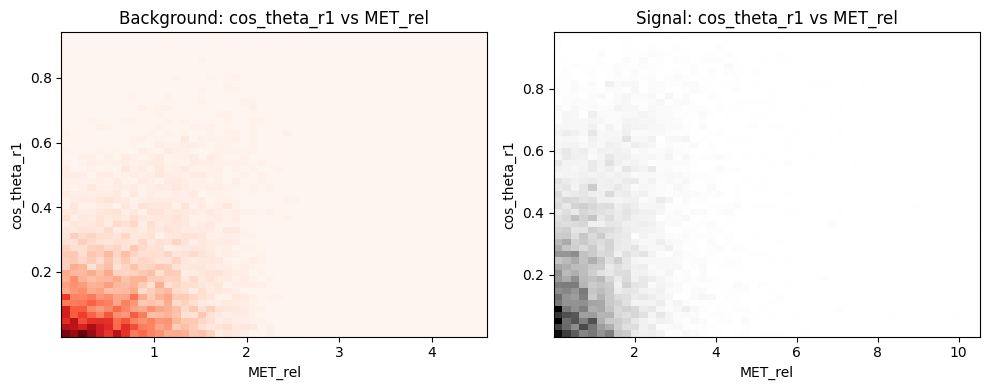

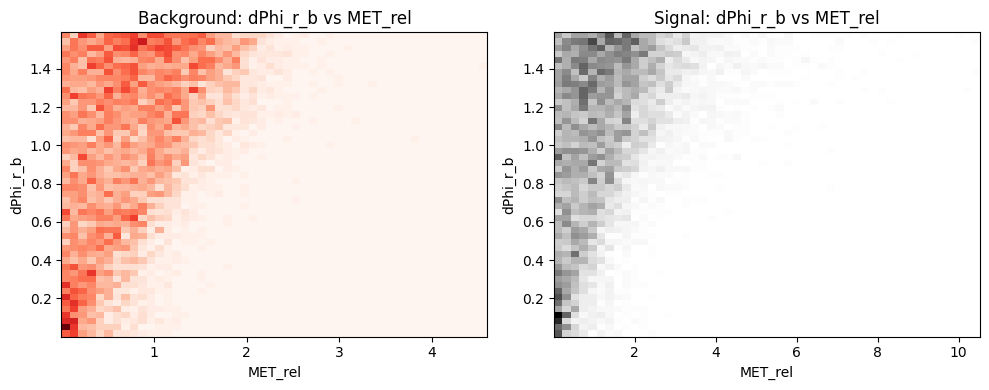

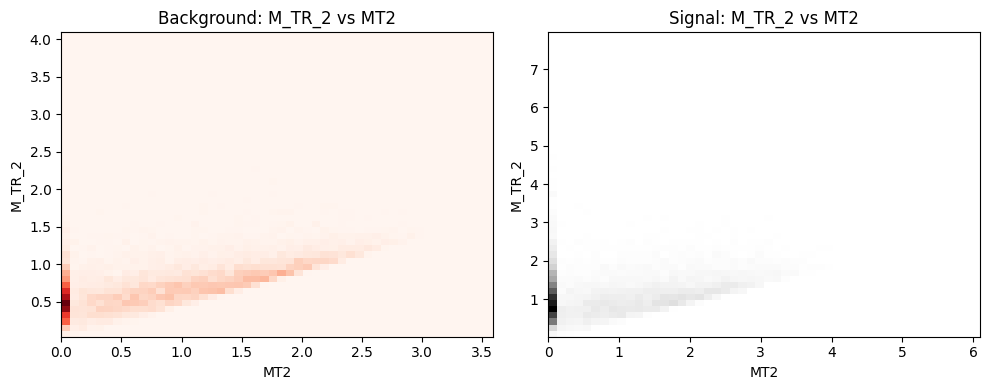

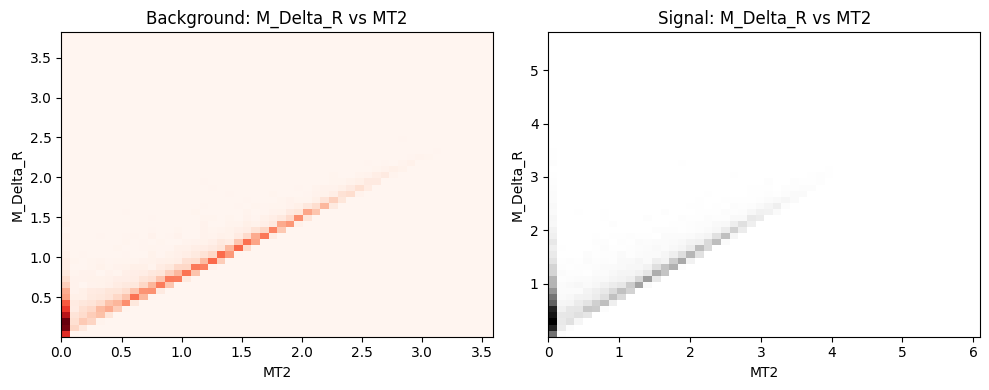

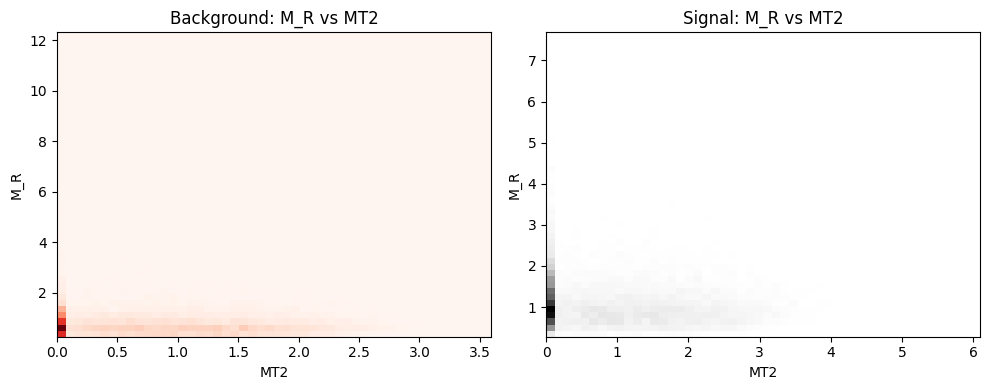

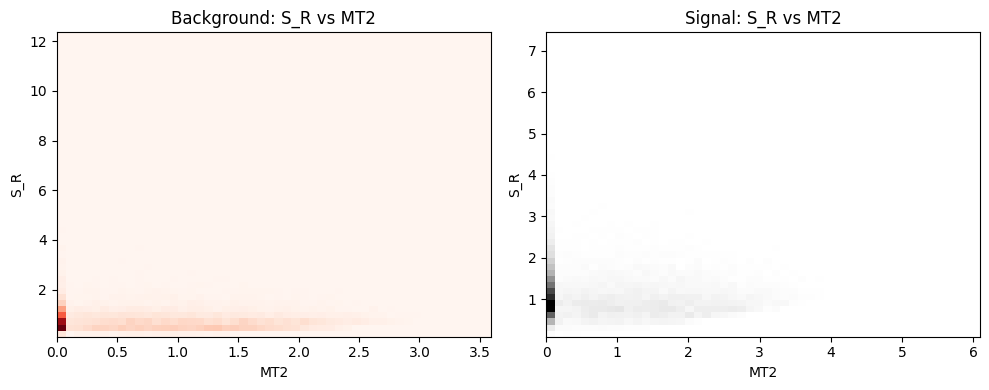

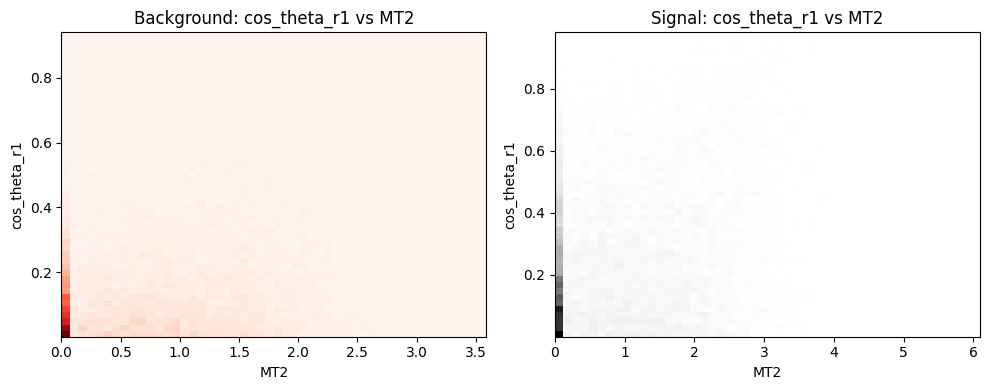

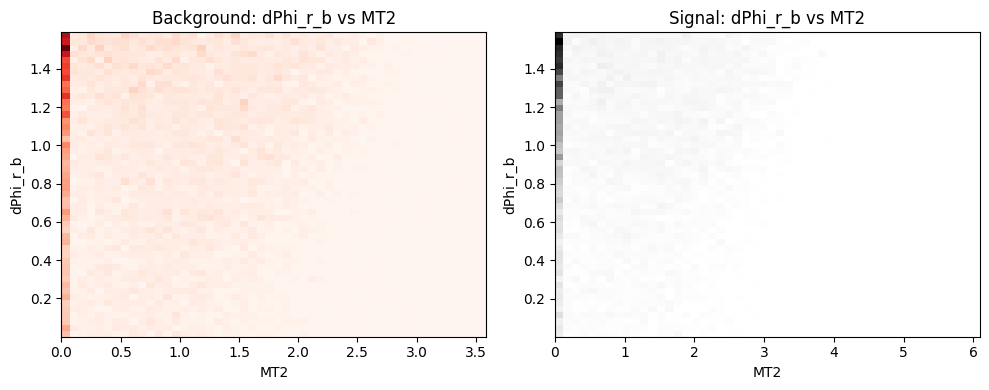

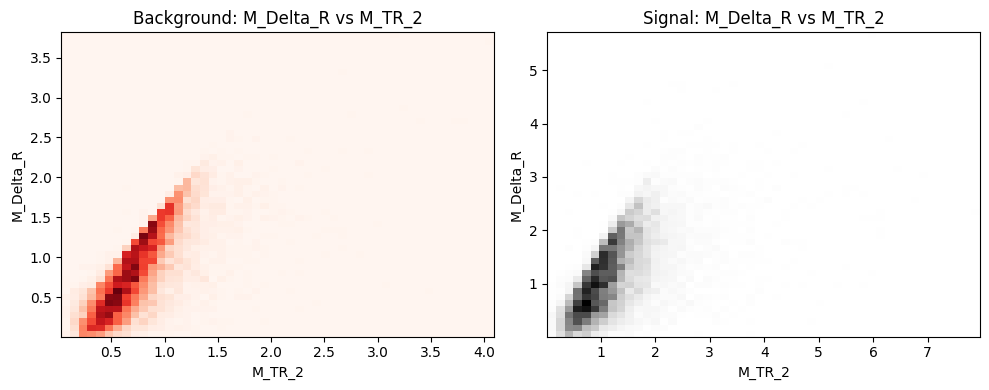

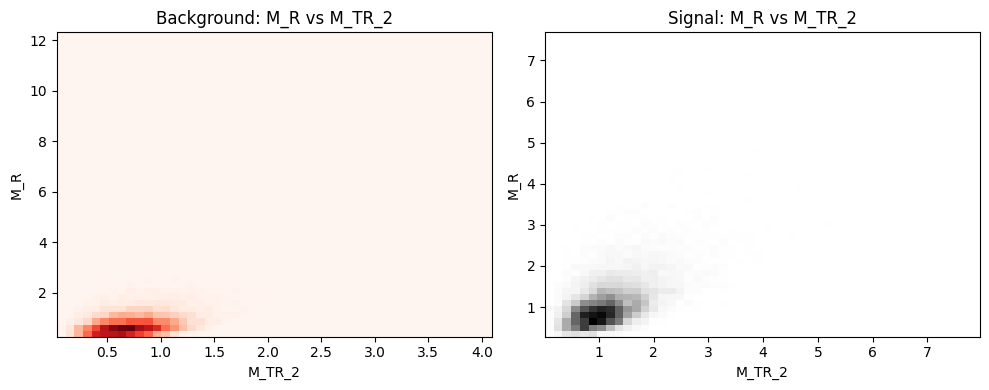

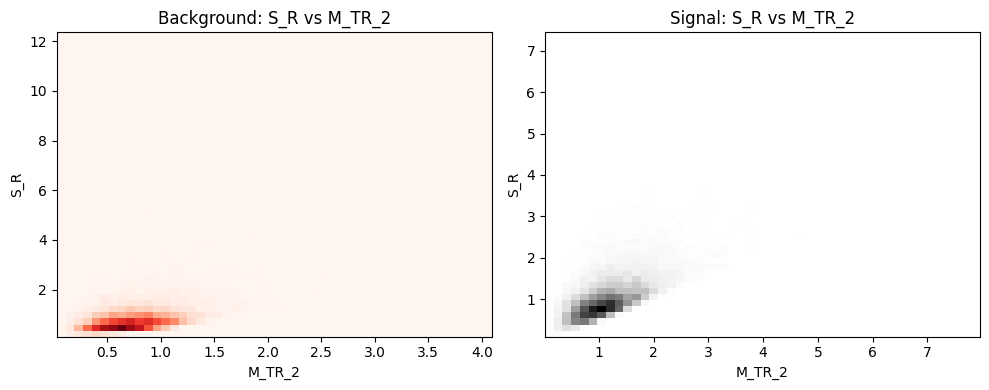

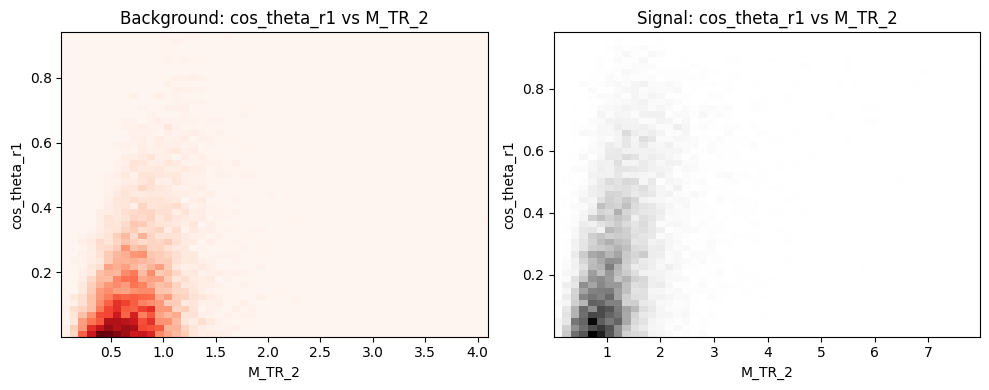

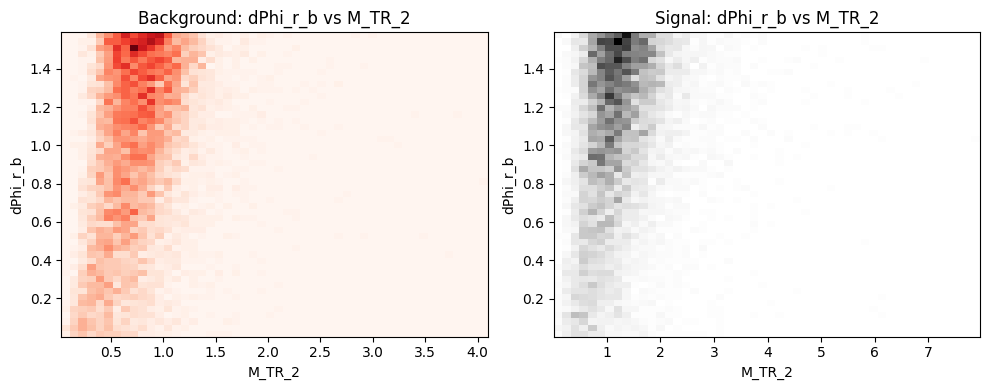

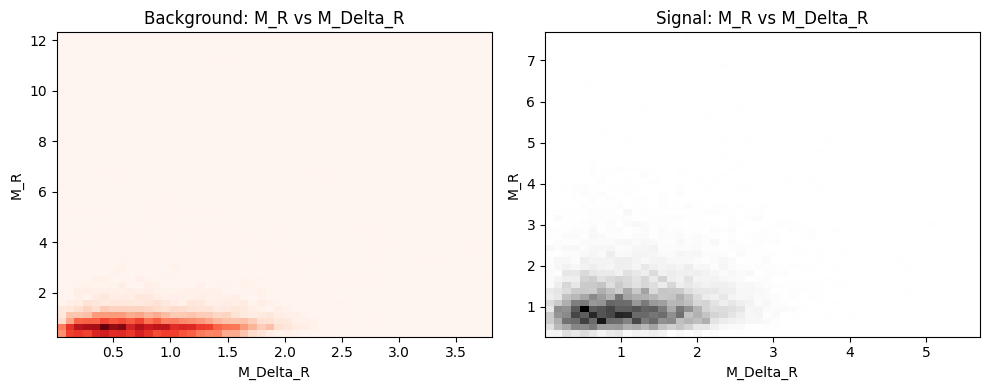

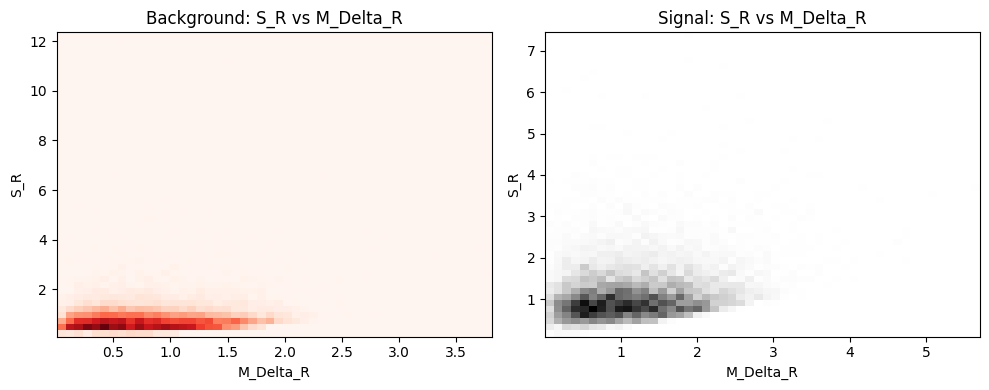

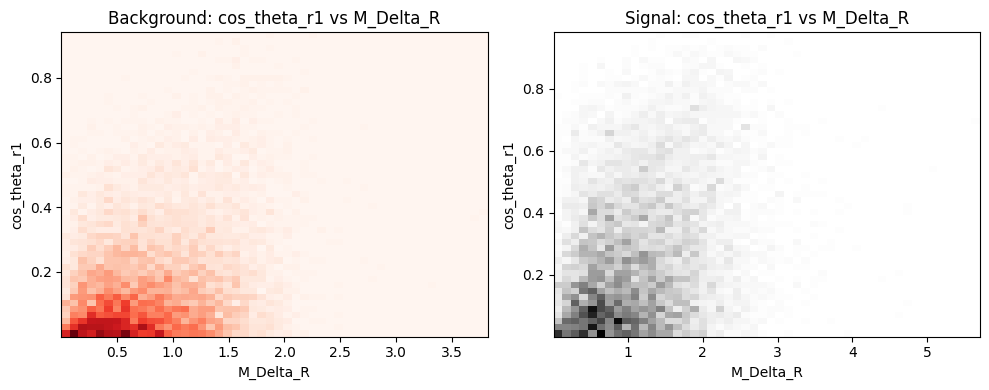

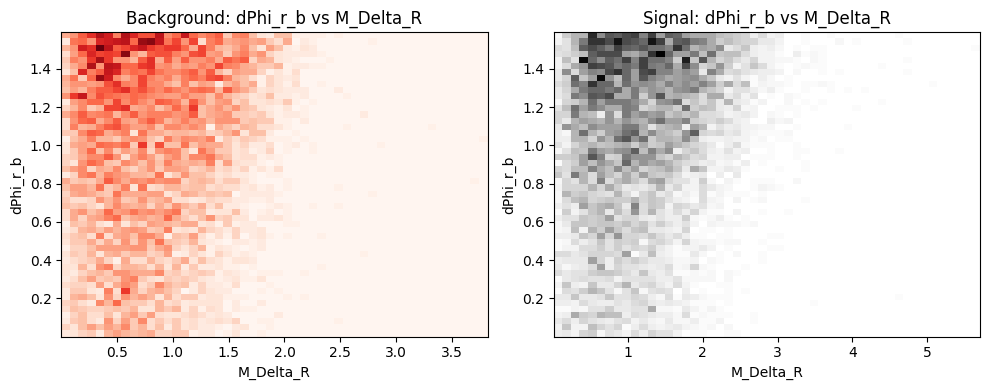

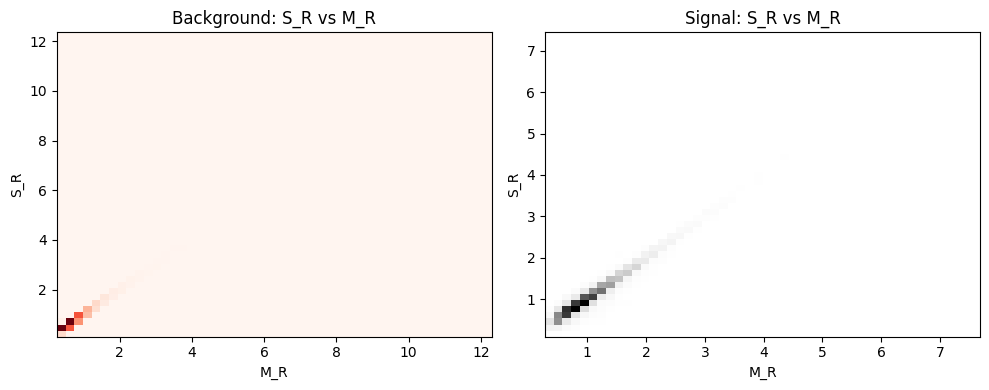

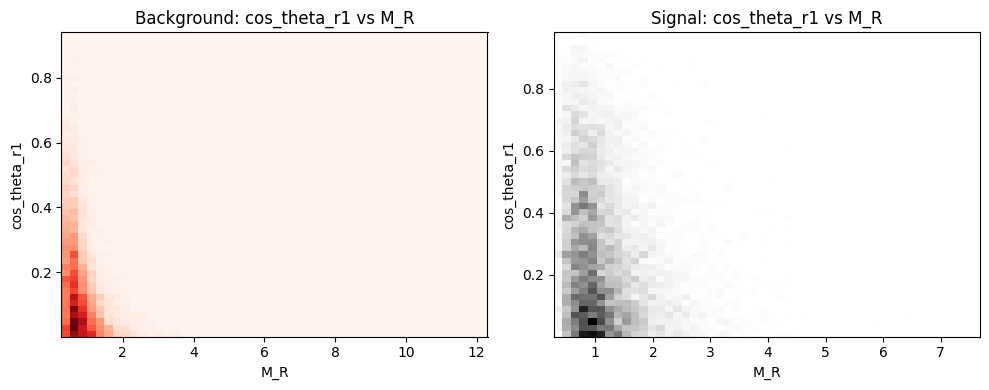

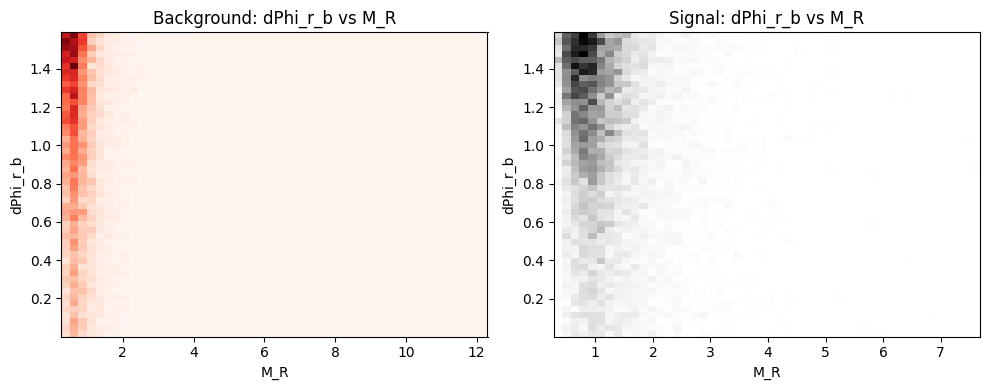

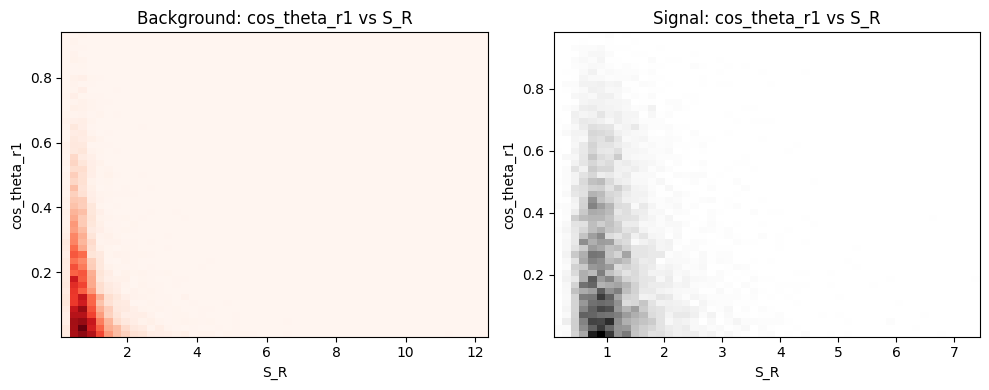

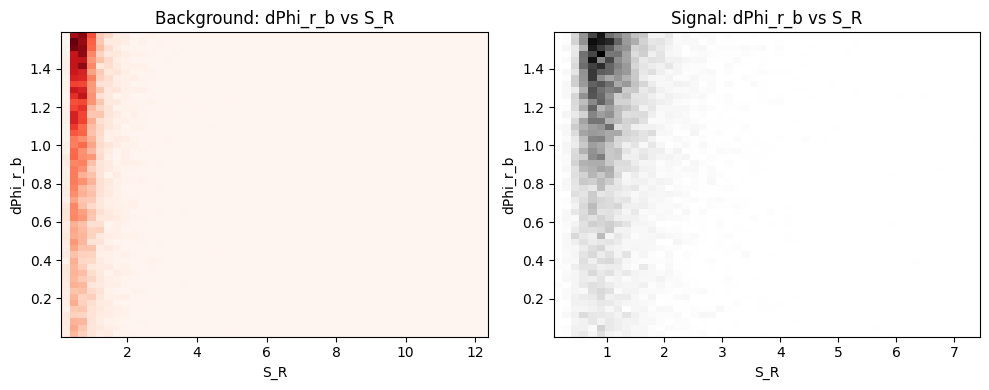

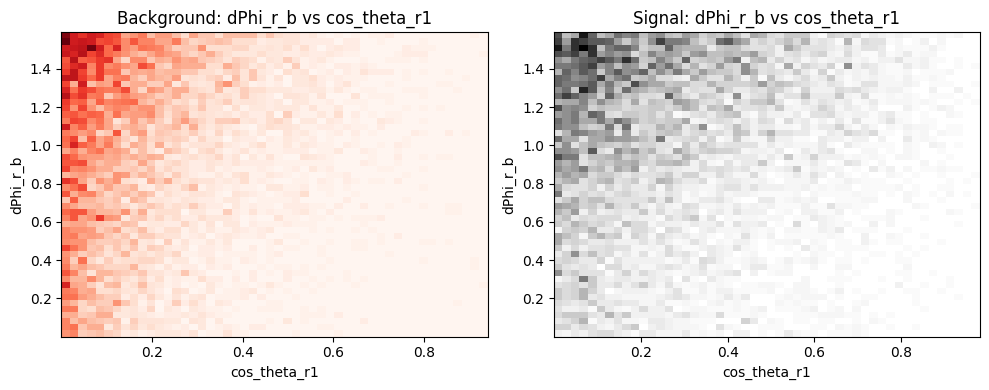

In [96]:
hist_pair(df_sig,df_bkg,high_level)

In [97]:
### part c
### The high level features show the most significant separation between the background and signal data points

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [98]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [99]:
### part a
### 'python3 -m pip install tabulate' in terminal

In [100]:
### part b
low_data = df[low_level].to_numpy()
high_data = df[high_level].to_numpy()

low_cov = np.cov(low_data, rowvar=False)
low_corr = np.corrcoef(low_data, rowvar=False)

high_cov = np.cov(high_data, rowvar=False)
high_corr = np.corrcoef(high_data, rowvar=False)

print(f"Low level covariace: {low_cov}")
print(f"Low level correlation: {low_corr}")
print(f"High level covariace: {high_cov}")
print(f"HIgh level covariace: {high_cov}")

Low level covariace: [[0.46748193 0.30503799 0.22843434]
 [0.30503799 0.42549016 0.07945188]
 [0.22843434 0.07945188 0.7622487 ]]
Low level correlation: [[1.         0.68395378 0.38267547]
 [0.68395378 1.         0.13951184]
 [0.38267547 0.13951184 1.        ]]
High level covariace: [[ 0.22157807 -0.18090014  0.24882357  0.23210005  0.10401425  0.16548304
  -0.11290414 -0.08335872  0.05816081  0.08709136]
 [-0.18090014  1.00537396 -0.1198512  -0.46099861 -0.18501679 -0.23307398
   0.01713455 -0.04138282 -0.05373485 -0.02511279]
 [ 0.24882357 -0.1198512   0.79048911  0.40877889  0.30199264  0.41474304
   0.04368455  0.08231538  0.05531787  0.1464394 ]
 [ 0.23210005 -0.46099861  0.40877889  0.73766054  0.18916951  0.43289693
  -0.03654441 -0.01103752  0.04462891  0.02089723]
 [ 0.10401425 -0.18501679  0.30199264  0.18916951  0.33782719  0.24186516
   0.20987467  0.2281247   0.05166586  0.05813297]
 [ 0.16548304 -0.23307398  0.41474304  0.43289693  0.24186516  0.38862381
   0.07393003  0.

In [101]:
### part c
from IPython.display import HTML, display
import tabulate

table = []
low_headers = [""] + low_level
high_headers = [""] + high_level

low_cov_table = [[low_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(low_cov)]
low_corr_table = [[low_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(low_corr)]
high_cov_table = [[high_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(high_cov)]
high_corr_table = [[high_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(high_corr)]


table.append(["--- Low-Level Covariance Matrix ---"] + [""] * (len(low_level)))
table += low_cov_table
table.append(["--- Low-Level Correlation Matrix ---"] + [""] * (len(low_level)))
table += low_corr_table
table.append(["--- High-Level Covariance Matrix ---"] + [""] * (len(high_level)))
table += high_cov_table
table.append(["--- High-Level Correlation Matrix ---"] + [""] * (len(high_level)))
table += high_corr_table

headers = [""] + (low_level if len(table[1]) - 1 == len(low_level) else high_level)
display(HTML(tabulate.tabulate(table, headers=headers, tablefmt='html')))

,l_1_pT,l_2_pT,MET
--- Low-Level Covariance Matrix ---,,,
l_1_pT,0.467,0.305,0.228
l_2_pT,0.305,0.425,0.079
MET,0.228,0.079,0.762
--- Low-Level Correlation Matrix ---,,,
l_1_pT,1.000,0.684,0.383
l_2_pT,0.684,1.000,0.140
MET,0.383,0.140,1.000
--- High-Level Covariance Matrix ---,,,
R,0.222,-0.181,0.249


In [102]:
def matrix_table(df,low_level,high_level):
    low_data = df[low_level].to_numpy()
    high_data = df[high_level].to_numpy()

    low_cov = np.cov(low_data, rowvar=False)
    low_corr = np.corrcoef(low_data, rowvar=False)
    high_cov = np.cov(high_data, rowvar=False)
    high_corr = np.corrcoef(high_data, rowvar=False)

    table = []
    low_headers = [""] + low_level
    high_headers = [""] + high_level

    low_cov_table = [[low_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(low_cov)]
    low_corr_table = [[low_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(low_corr)]
    high_cov_table = [[high_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(high_cov)]
    high_corr_table = [[high_level[i]] + [f"{val:.3f}" for val in row] for i, row in enumerate(high_corr)]


    table.append(["--- Low-Level Covariance Matrix ---"] + [""] * (len(low_level)))
    table += low_cov_table
    table.append(["--- Low-Level Correlation Matrix ---"] + [""] * (len(low_level)))
    table += low_corr_table
    table.append(["--- High-Level Covariance Matrix ---"] + [""] * (len(high_level)))
    table += high_cov_table
    table.append(["--- High-Level Correlation Matrix ---"] + [""] * (len(high_level)))
    table += high_corr_table

    headers = [""] + (low_level if len(table[1]) - 1 == len(low_level) else high_level)
    display(HTML(tabulate.tabulate(table, headers=headers, tablefmt='html')))

In [103]:
matrix_table(df,low_level,high_level)

,l_1_pT,l_2_pT,MET
--- Low-Level Covariance Matrix ---,,,
l_1_pT,0.467,0.305,0.228
l_2_pT,0.305,0.425,0.079
MET,0.228,0.079,0.762
--- Low-Level Correlation Matrix ---,,,
l_1_pT,1.000,0.684,0.383
l_2_pT,0.684,1.000,0.140
MET,0.383,0.140,1.000
--- High-Level Covariance Matrix ---,,,
R,0.222,-0.181,0.249


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [104]:
### 5.1
### separation was most clearly visible in high-level variables, so using those to analyze the distribution via the mean and std
for var in high_level:
    sig_mean = df_sig[var].mean()
    bkg_mean = df_bkg[var].mean()
    sig_std = df_sig[var].std()
    bkg_std = df_bkg[var].std()
    print("------------------------------------------------------------------------")
    print(f"{var:15} | Signal Mean: {sig_mean:.3f} | Background Mean: {bkg_mean:.3f}")
    print(f"{var:15} | Signal STD: {sig_mean:.3f} | Background STD: {bkg_mean:.3f}")
    print("------------------------------------------------------------------------")

------------------------------------------------------------------------
R               | Signal Mean: 1.056 | Background Mean: 0.953
R               | Signal STD: 1.056 | Background STD: 0.953
------------------------------------------------------------------------
------------------------------------------------------------------------
axial_MET       | Signal Mean: 0.089 | Background Mean: -0.070
axial_MET       | Signal STD: 0.089 | Background STD: -0.070
------------------------------------------------------------------------
------------------------------------------------------------------------
MET_rel         | Signal Mean: 1.275 | Background Mean: 0.770
MET_rel         | Signal STD: 1.275 | Background STD: 0.770
------------------------------------------------------------------------
------------------------------------------------------------------------
MT2             | Signal Mean: 1.075 | Background Mean: 0.937
MT2             | Signal STD: 1.075 | Background STD: 0.937

In [105]:
### the mean and STD of the signal data distributions is greater than that of the background distribution, so 
### the correct strategy will by x > xc

In [106]:
### 5.2
def plot_tpr_fpr(var):
    sig = df_sig[var].values
    bkg = df_bkg[var].values
    x_c = np.linspace(df[var].min(), df[var].max(), 200)

    tpr = [(sig > x).sum() / len(sig) for x in x_c]
    fpr = [(bkg > x).sum() / len(bkg) for x in x_c]

    plt.figure(figsize=(6, 4))
    plt.plot(x_c, tpr, label="True Positive Rate", color="black")
    plt.plot(x_c, fpr, label="FAlse Positive Rate)", color="red")
    plt.ylabel("Efficiency")
    plt.title(f"TPR / FPR vs. $x_c$ for {var} (using $x > x_c$)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return x_c, np.array(tpr), np.array(fpr)

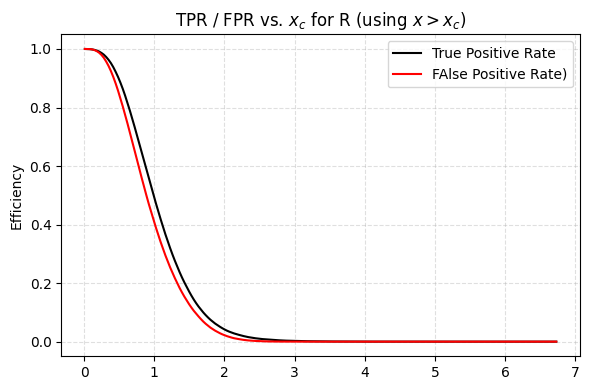

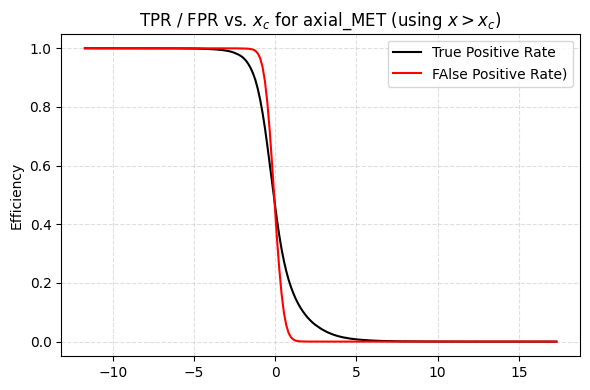

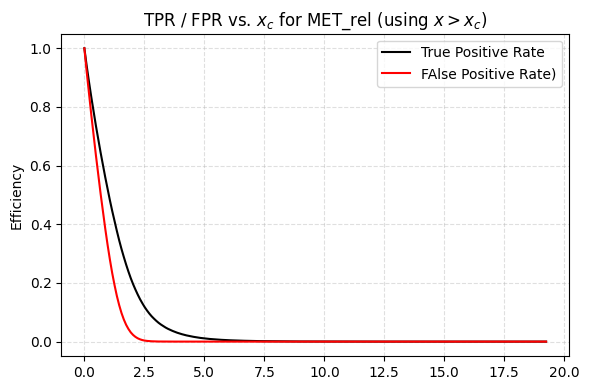

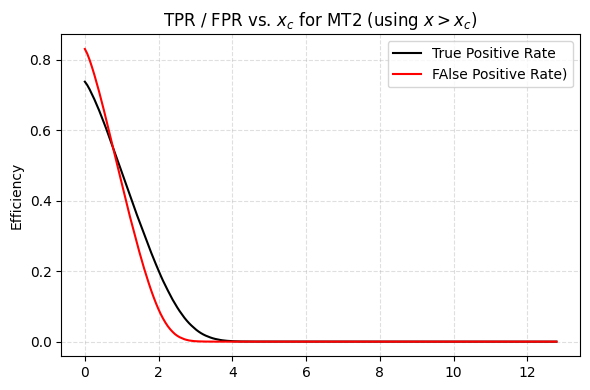

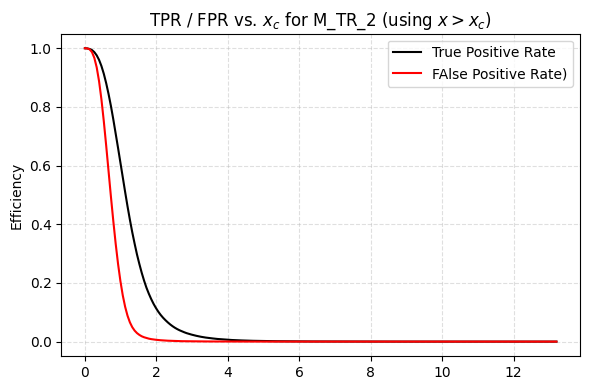

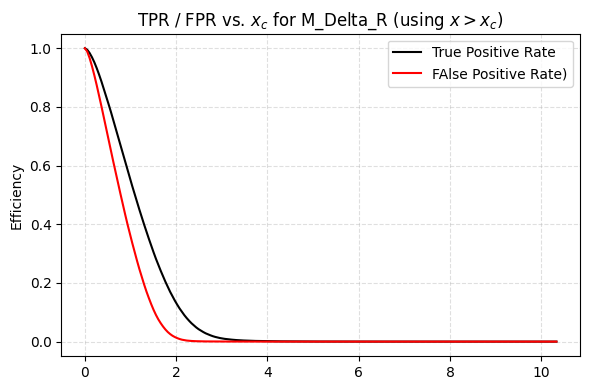

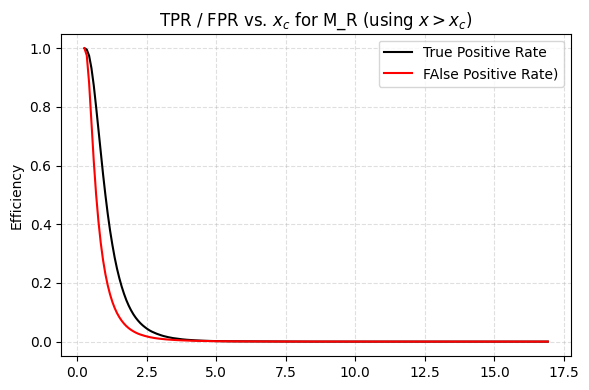

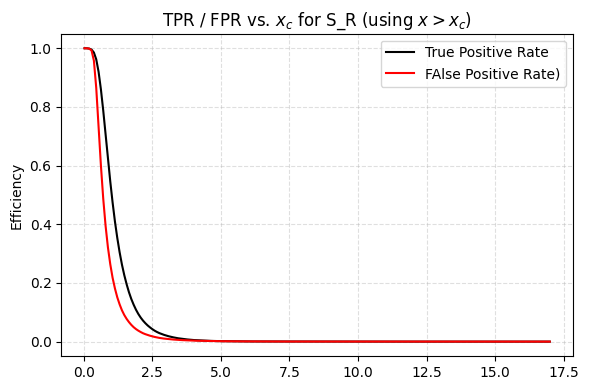

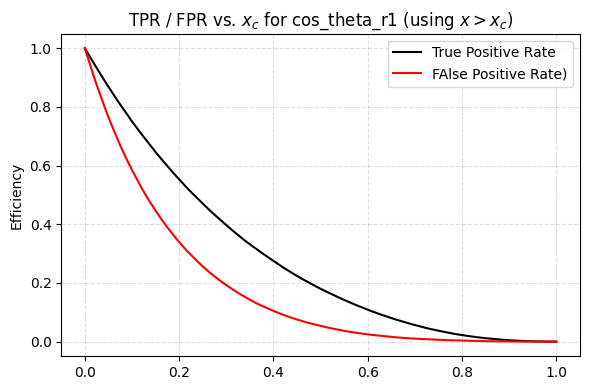

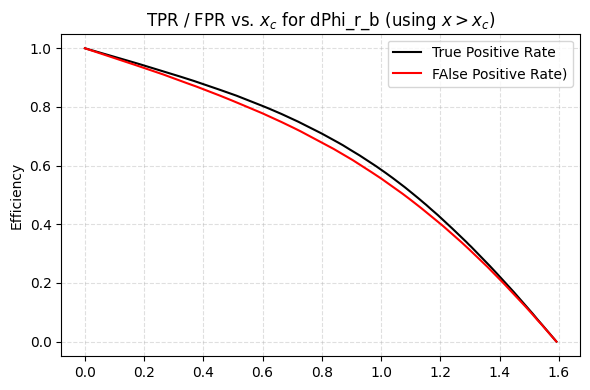

In [107]:
for var in high_level:
    plot_tpr_fpr(var)

In [108]:
### 5.3
def tpr_fpr(var):
    sig = df_sig[var].values
    bkg = df_bkg[var].values
    x_c = np.linspace(df[var].min(), df[var].max(), 200)
    tpr = [(sig > x).sum() / len(sig) for x in x_c]
    fpr = [(bkg > x).sum() / len(bkg) for x in x_c]
    return x_c, np.array(tpr), np.array(fpr)

def plot_signif(var, x_c, tpr, fpr):
    Ns = [10, 100, 1000, 10000]
    Nb = [100, 1000, 10000, 100000]

    plt.figure(figsize=(8, 6))
    for ns, nb in zip(Ns, Nb):
        Nsp = tpr * ns
        Nbp = fpr * nb
        sigma = Nsp / np.sqrt(Nsp + Nbp + 1e-10)
        plt.plot(x_c, sigma, label=f"$N_S$={ns}, $N_B$={nb}")

    plt.xlabel(f"{var} Threshold ($x_c$)")
    plt.ylabel("Significance $\\sigma_{S'}$")
    plt.title(f"Significance vs. $x_c$ for {var}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

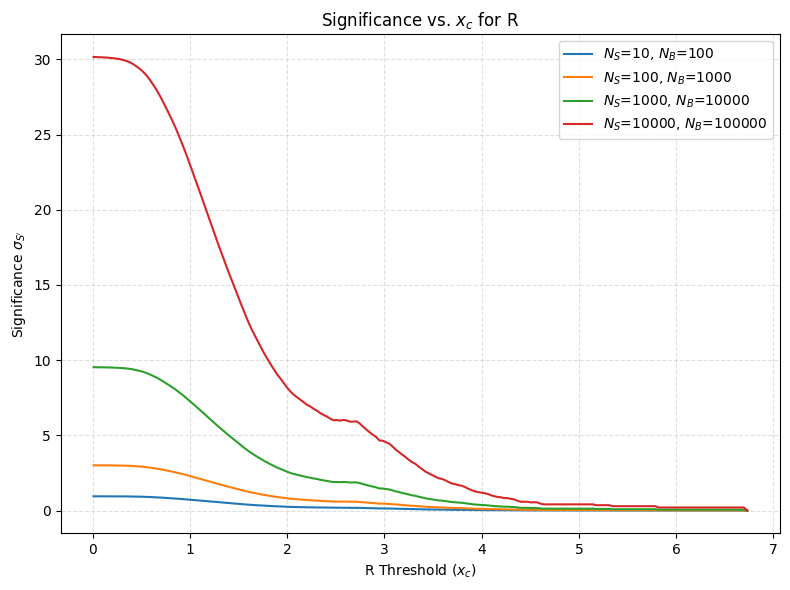

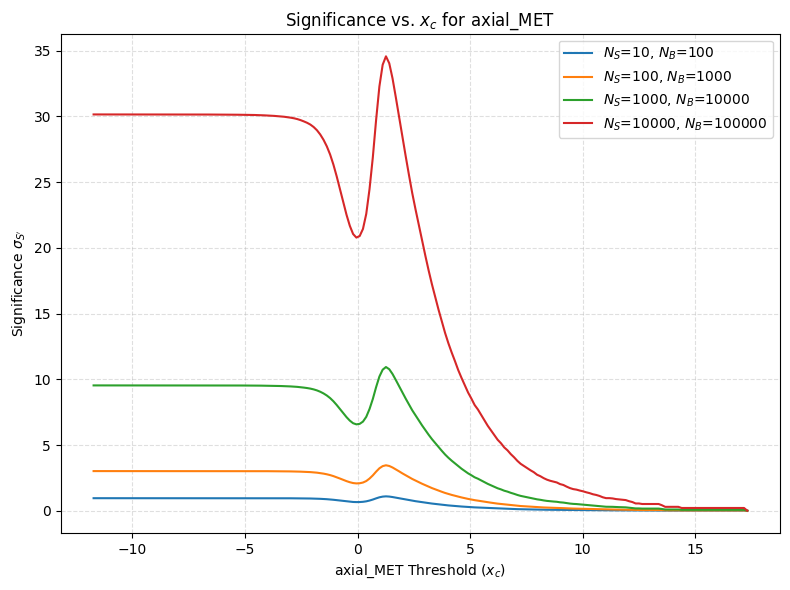

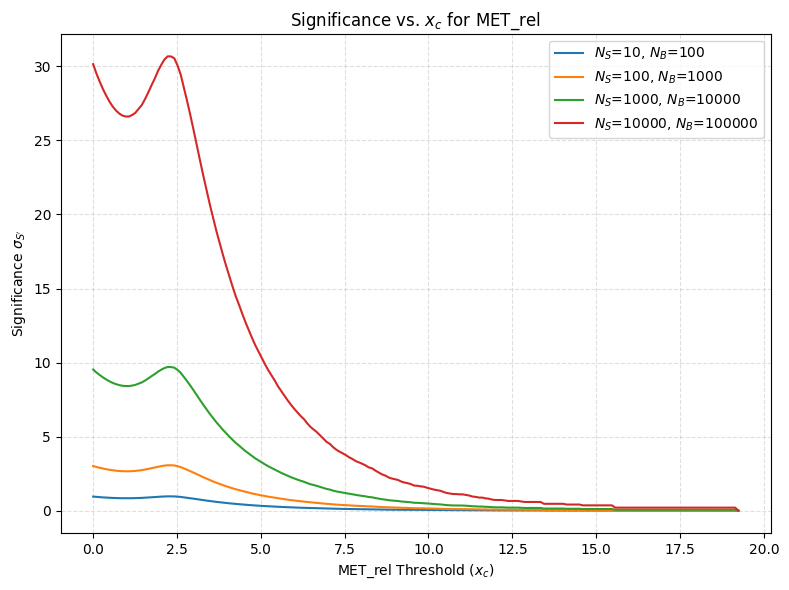

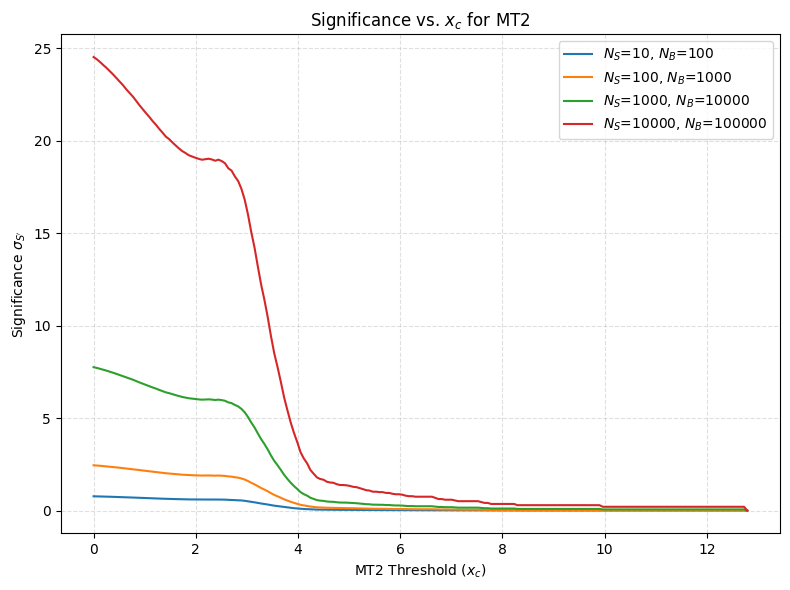

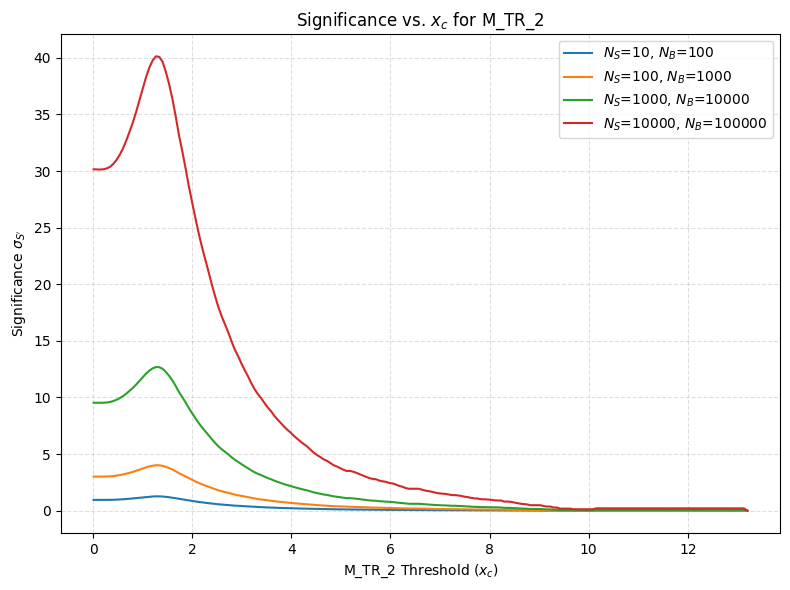

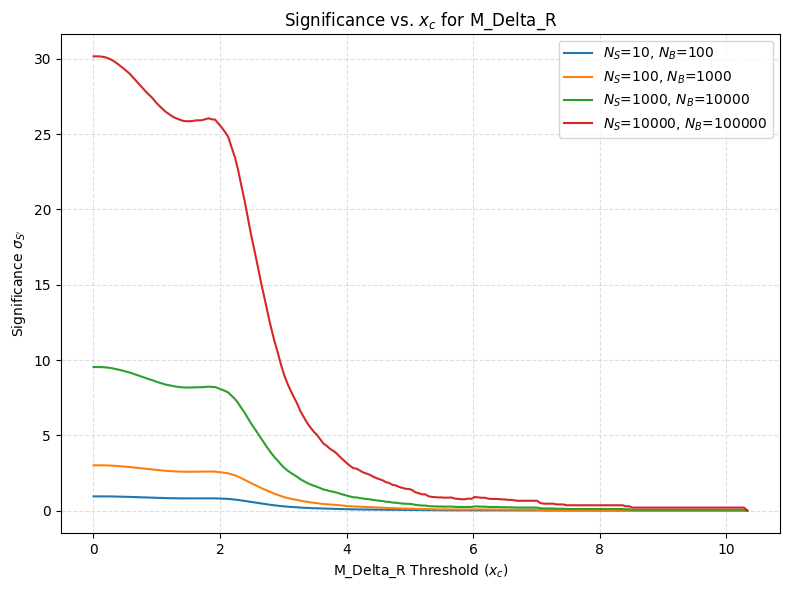

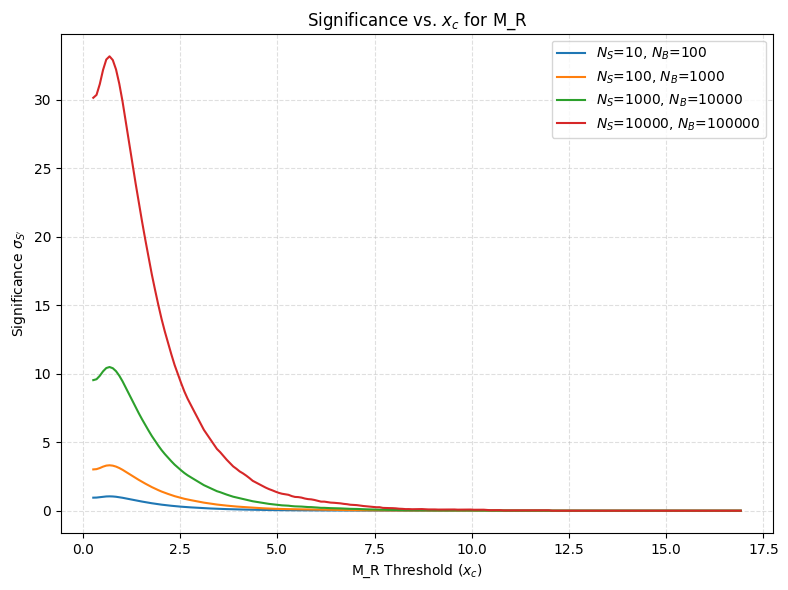

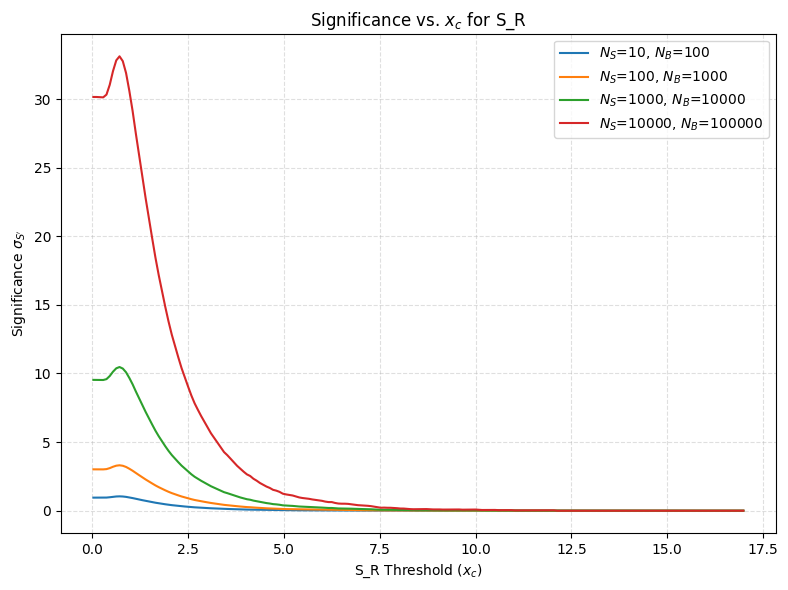

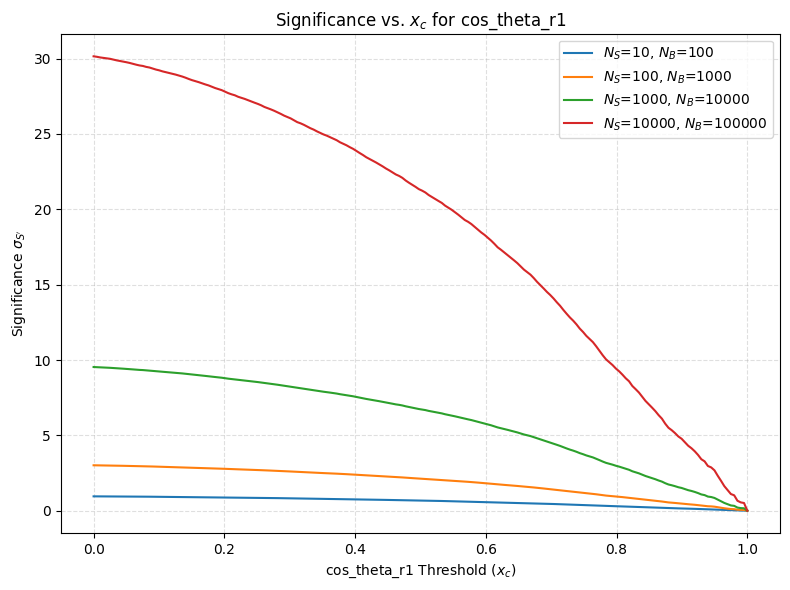

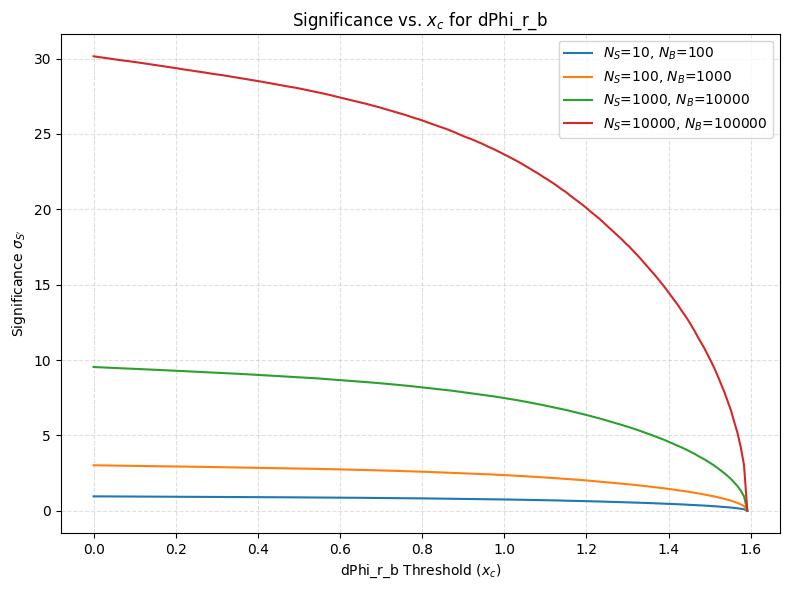

In [109]:
for var in high_level:
    x_c,tpr,fpr = tpr_fpr(var)
    plot_signif(var,x_c,tpr,fpr)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [110]:
### 6.1
### the variables with the highest significance were 'axial_MET','M_TR_2', and "S_R', so we'll use those
cut = ['axial_MET','M_TR_2','S_R']
Ns, Nb = 1000, 10000
best_cuts = {}
for var in cut:
    x_c,tpr,fpr = tpr_fpr(var)
    sig = (tpr * Ns) / np.sqrt((tpr * Ns) + (fpr * Nb) + 1e-10)
    best_idx = np.argmax(sig)
    best_threshold = x_c[best_idx]
    best_sigma = sig[best_idx]
    best_cuts[var] = best_threshold
    print(f"{var}: best threshold = {best_threshold}, max σ = {best_sigma}")

axial_MET: best threshold = 1.2636392775492453, max σ = 10.932959829788937
M_TR_2: best threshold = 1.2689573700029646, max σ = 12.690308188595377
S_R: best threshold = 0.7092284330508517, max σ = 10.471425324984324


In [111]:
### 6.2
sig = df_sig.copy()
bkg = df_bkg.copy()
Ns0 = len(sig)
Nb0 = len(bkg)
cutflow = []
for var, x_c in best_cuts.items():
    sig = sig[sig[var] > x_c]
    bkg = bkg[bkg[var] > x_c]
    eps_s = len(sig) / Ns0
    eps_b = len(bkg) / Nb0
    Nsp = eps_s * Ns
    Nbp = eps_b * Nb
    sigma = Nsp / np.sqrt(Nsp + Nbp + 1e-10)
    cutflow.append([
        var,
        f"{x_c}",
        f"{eps_s}",
        f"{eps_b}",
        int(Nsp),
        int(Nbp),
        f"{sigma}"
    ])
headers = ["Variable","x_c","ε_S","ε_B","N'_S","N'_B","σ_S'"]
display(HTML(tabulate.tabulate(cutflow, headers=headers, tablefmt="html")))

Variable,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
axial_MET,1.26364,0.14563,0.00318,145,31,10.933
M_TR_2,1.26896,0.0632991,0.000406271,63,4,7.71242
S_R,0.709228,0.0631726,0.000406271,63,4,7.70424


In [112]:
### 6.3
### high correlation variables: MET_rel & M_Delta_R 0.748, 
def sig_order(var1, var2, x_cut1):
    sig_cond = df_sig[df_sig[var1] > x_cut1]
    bkg_cond = df_bkg[df_bkg[var1] > x_cut1]
    sig_vals = sig_cond[var2].values
    bkg_vals = bkg_cond[var2].values
    x_vals = np.linspace(df[var2].min(), df[var2].max(), 200)
    tpr = [(sig_vals > x).sum() / len(df_sig) for x in x_vals]
    fpr = [(bkg_vals > x).sum() / len(df_bkg) for x in x_vals]

    Nsp = np.array(tpr) * Ns
    Nbp = np.array(fpr) * Nb
    sigma = Nsp / np.sqrt(Nsp + Nbp + 1e-10)
    best_idx = np.argmax(sigma)
    best_x = x_vals[best_idx]
    best_sigma = sigma[best_idx]

    plt.figure(figsize=(6, 4))
    plt.plot(x_vals, sigma, color="black")
    plt.axvline(best_x, color="green", linestyle="--", label=f"Best $x_c$ = {best_x}")
    plt.title(f"{var2} optimization after {var1} > {x_cut1}")
    plt.xlabel(f"{var2} threshold ($x_c$)")
    plt.ylabel("Significance $\\sigma$")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"Optimizing {var2} after {var1} > {x_cut1}")
    print(f"Max σ = {best_sigma} at {var2} > {best_x}")

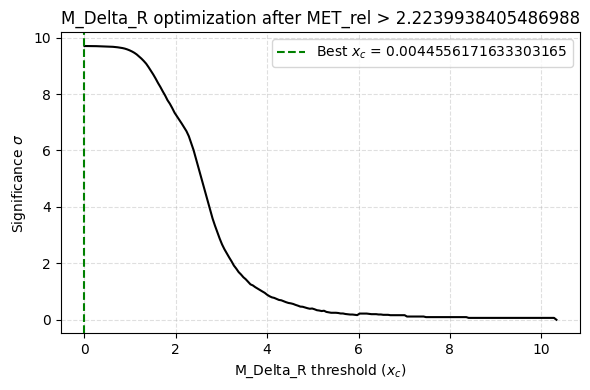

Optimizing M_Delta_R after MET_rel > 2.2239938405486988
Max σ = 9.70158772309368 at M_Delta_R > 0.0044556171633303165


In [113]:
x_c,tpr,fpr = tpr_fpr("MET_rel")
sig = (tpr * Ns) / np.sqrt((tpr * Ns) + (fpr * Nb) + 1e-10)
best_idx = np.argmax(sig)
best_cuts["MET_rel"] = x_c[best_idx]
sig_order("MET_rel", "M_Delta_R", best_cuts["MET_rel"])

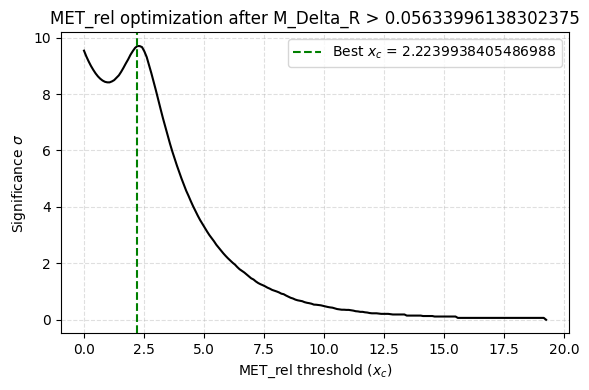

Optimizing MET_rel after M_Delta_R > 0.05633996138302375
Max σ = 9.701214811469448 at MET_rel > 2.2239938405486988


In [114]:
x_c, tpr, fpr = tpr_fpr("M_Delta_R")
sig = (tpr * Ns) / np.sqrt((tpr * Ns) + (fpr * Nb) + 1e-10)
best_idx = np.argmax(sig)
best_cuts["M_Delta_R"] = x_c[best_idx]
sig_order("M_Delta_R", "MET_rel", best_cuts["M_Delta_R"])

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



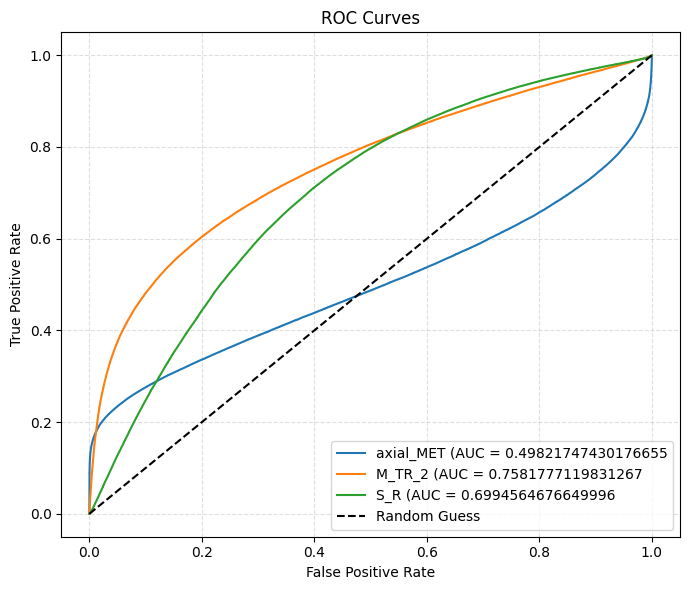

In [115]:
### 7.1
from sklearn.metrics import roc_curve, auc
top_vars = ["axial_MET", "M_TR_2", "S_R"]

plt.figure(figsize=(7, 6))
for var in top_vars:
    y_sig = df_sig[var].values
    y_bkg = df_bkg[var].values
    y_true = np.concatenate([np.ones(len(y_sig)), np.zeros(len(y_bkg))])
    y_scores = np.concatenate([y_sig, y_bkg])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_score}")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
### 7.2
def roc_plot(variables,df_sig,df_bkg,title="ROC Curves"):
    plt.figure(figsize=(7, 6))
    for var in variables:
        y_sig = df_sig[var].values
        y_bkg = df_bkg[var].values
        y_true = np.concatenate([np.ones(len(y_sig)), np.zeros(len(y_bkg))])
        y_scores = np.concatenate([y_sig, y_bkg])
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{var} (AUC = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

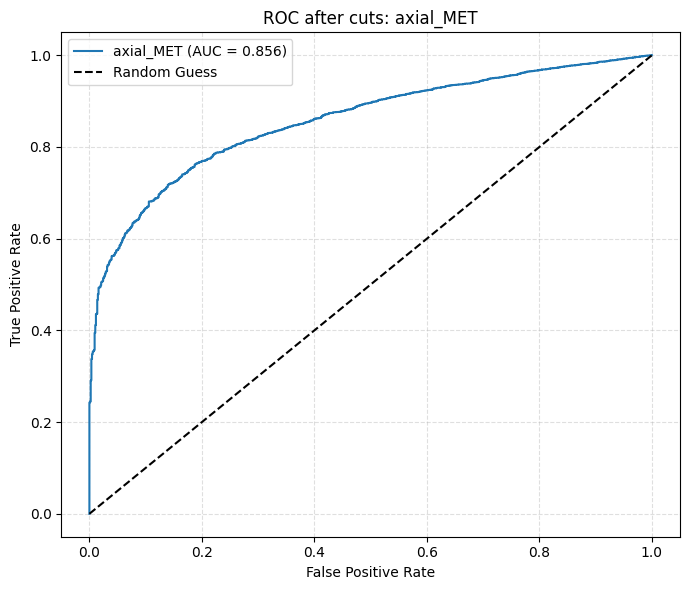

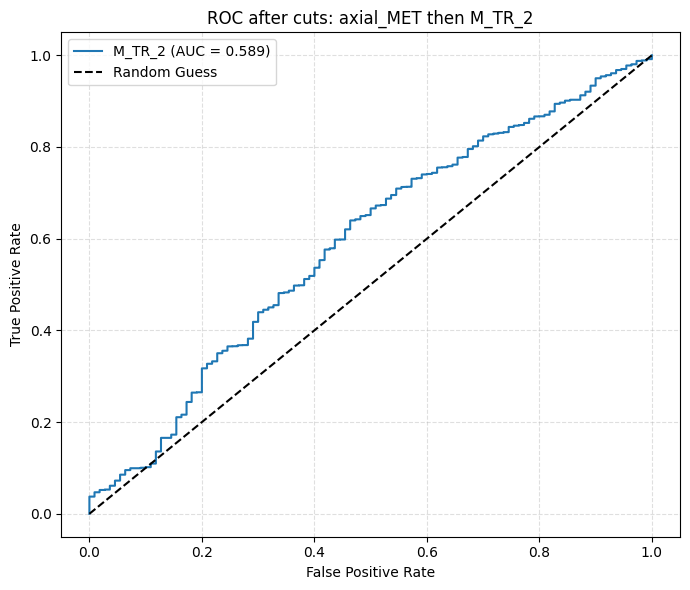

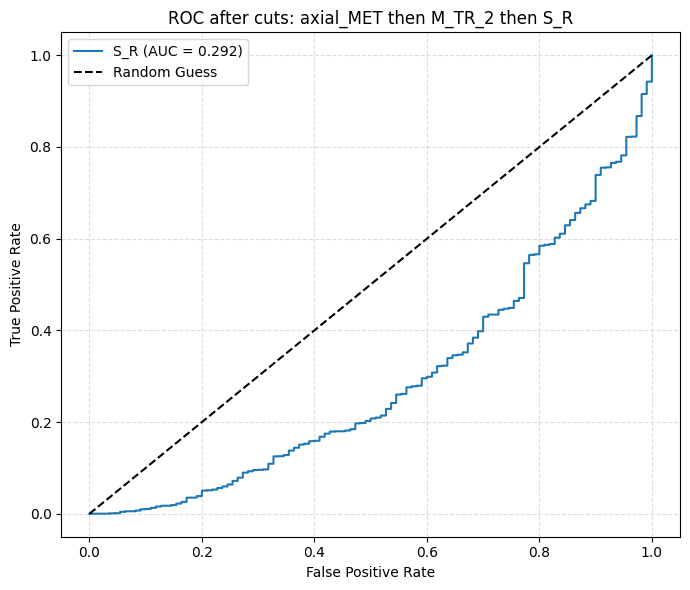

In [117]:
### 7.3
cuts = ["axial_MET","M_TR_2","S_R"]
sig = df_sig.copy()
bkg = df_bkg.copy()
for i in range(len(cuts)):
    for j in range(i+1):
        cut_var = cuts[j]
        threshold = best_cuts[cut_var]
        sig = sig[sig[cut_var] > threshold]
        bkg = bkg[bkg[cut_var] > threshold]    
    label = " then ".join(cuts[:i+1])
    roc_plot([cuts[i]], sig, bkg, title=f"ROC after cuts: {label}")

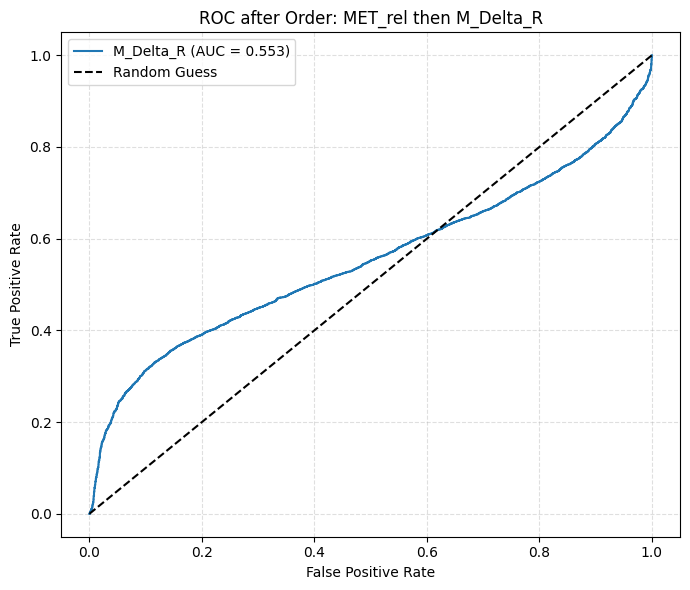

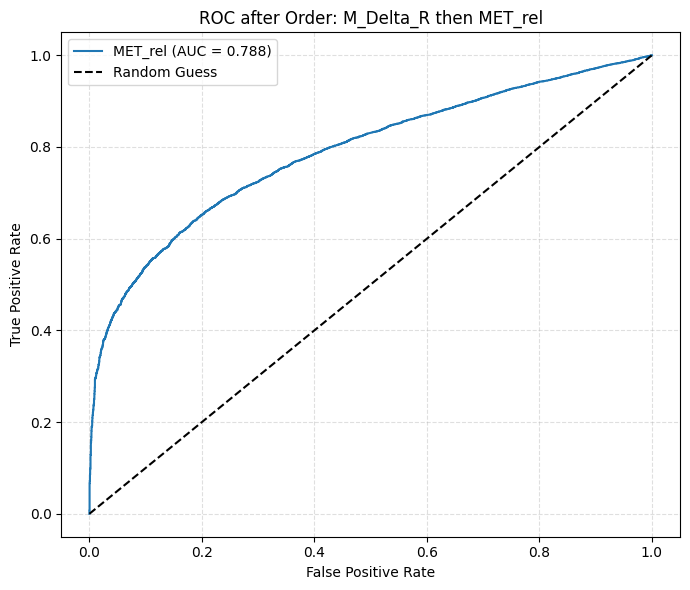

In [118]:
### 7.4
order1 = ["MET_rel","M_Delta_R"]
order2 = ["M_Delta_R","MET_rel"]
def order_plot(order, label):
    sig = df_sig.copy()
    bkg = df_bkg.copy()
    for var in order:
        sig = sig[sig[var] > best_cuts[var]]
        bkg = bkg[bkg[var] > best_cuts[var]]
    roc_plot([order[-1]], sig, bkg, title=f"ROC after {label}")

order_plot(order1, "Order: MET_rel then M_Delta_R")
order_plot(order2, "Order: M_Delta_R then MET_rel")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [119]:
### 8.1
features = ["axial_MET", "M_TR_2", "S_R"]
X1 = df_sig[features].values
X2 = df_bkg[features].values
m1 = np.mean(X1, axis=0)
m2 = np.mean(X2, axis=0)
SB = np.outer(m2 - m1, m2 - m1)
SW = np.zeros((len(features), len(features)))
for x in X1:
    diff = (x - m1).reshape(-1, 1)
    SW += diff @ diff.T
for x in X2:
    diff = (x - m2).reshape(-1, 1)
    SW += diff @ diff.T

print(f"SB Matrix:\n {SB}")
print(f"SW Matrix:\n {SW}")

SB Matrix:
 [[0.02536508 0.07911074 0.05171263]
 [0.07911074 0.24673725 0.16128571]
 [0.05171263 0.16128571 0.10542826]]
SW Matrix:
 [[ 499537.19374007 -102328.89730286  -27110.89596659]
 [-102328.89730286  138283.67705922   94040.3634651 ]
 [ -27110.89596659   94040.3634651   177919.22026408]]


In [120]:
### 8.2
w = np.linalg.inv(SW) @ (m2 - m1)
F_sig = X1 @ w
F_bkg = X2 @ w

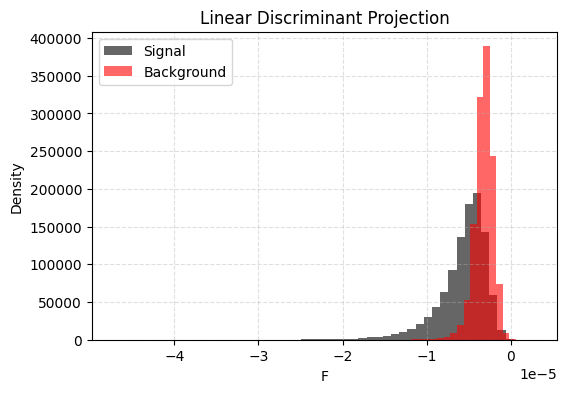

In [121]:
plt.figure(figsize=(6, 4))
plt.hist(F_sig, bins=50, alpha=0.6, label="Signal", density=True, color="black")
plt.hist(F_bkg, bins=50, alpha=0.6, label="Background", density=True, color="red")
plt.title("Linear Discriminant Projection")
plt.xlabel("F")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

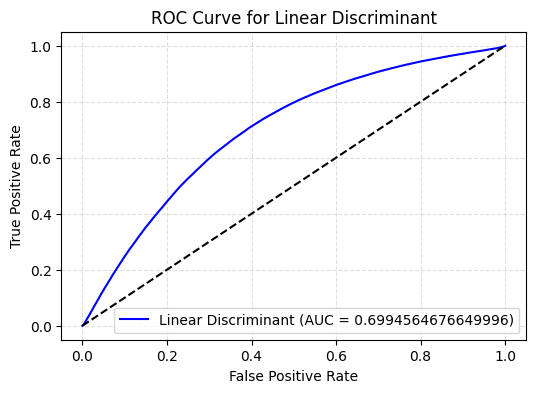

In [122]:
### 8.3
y_true = np.concatenate([np.ones(len(F_sig)), np.zeros(len(F_bkg))])
y_hat = np.concatenate([F_sig, F_bkg])
fpr,tpr, _ = roc_curve(y_true, y_scores)
auc_hat = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Linear Discriminant (AUC = {auc_score})", color="blue")
plt.plot([0, 1],[0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Linear Discriminant")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [124]:
### 8.4
x_c = np.linspace(min(y_hat), max(y_hat), 200)
eps_s = [(F_sig > x).sum() / len(F_sig) for x in x_c]
eps_b = [(F_bkg > x).sum() / len(F_bkg) for x in x_c]
eps_s = np.array(eps_s)
eps_b = np.array(eps_b)
Ns_values = [10,100,1000,10000]
Nb_values = [100,1000,10000,100000]

for Ns, Nb in zip(Ns_values, Nb_values):
    Nsp = eps_s * Ns
    Nbp = eps_b * Nb
    sigma = Nsp / np.sqrt(Nsp + Nbp + 1e-10)
    max_sigma = np.max(sigma)
    print(f"Scenario Ns={Ns}, Nb={Nb}: max σ = {max_sigma}")

Scenario Ns=10, Nb=100: max σ = 0.9534586191539604
Scenario Ns=100, Nb=1000: max σ = 3.015100891246793
Scenario Ns=1000, Nb=10000: max σ = 9.534586191543895
Scenario Ns=10000, Nb=100000: max σ = 30.15100891246929
